# Deterioration Risk Prediction in the Emergency Department
## A Survival Analysis Approach for the Triagegeist Competition

**The Objective is a decision support system that surfaces deterioration risk for patients already waiting.**

---

### The Clinical Problem

When a patient arrives in the Emergency Department (ED), a triage nurse quickly evaluates their condition and assigns an **acuity level** using the ESI (Emergency Severity Index) scale, from 1 (immediate, life-threatening) to 5 (non-urgent). This score determines how fast the patient will be seen and what resources are allocated.

But triage is a snapshot - a decision made in minutes, based on limited information. Sometimes a patient triaged as "not urgent" (ESI 3, 4, or 5) actually has a hidden or evolving condition that will worsen over time. This is called **undertriage**: the patient's real severity was underestimated. These patients sit in the waiting room while their condition silently deteriorates.

Cheng et al. (2025, BMC Emergency Medicine) showed that patients who require unexpected ICU (Intensive Care Unit) transfer within 24 hours of admission experience significantly increased mortality and length of stay. Their study used machine learning to predict adverse events (cardiac arrest, mechanical ventilation, ICU transfer) from ED data, achieving AUCs of 0.778-0.902. Our work builds on the same clinical intuition, but frames the problem differently: instead of asking "will this patient deteriorate yes/no?", we ask **"how does this patient's risk of deterioration evolve over time?"**

---

### What is Survival Analysis?

Survival analysis is a family of statistical methods designed to study **"how long until an event happens."** It was originally developed in medical research to study patient mortality, but today it is applied in many domains: in oncology, the event is cancer recurrence; in engineering, equipment failure; in customer analytics, churn. In our case, the event is **clinical deterioration while waiting in the ED**.

What makes survival analysis different from standard regression or classification is its ability to handle **censored data** - patients for whom we know *some* information about their time, but we didn't observe the actual event. For example, a patient discharged after 2 hours didn't deteriorate *during those 2 hours*, but we can't say they would never deteriorate if they had stayed longer. Standard models would either discard this patient (losing information) or treat them as a negative case (ignoring the time dimension). Survival models use all the available information.

#### The Data Format: (T, E, X)

For each patient, survival analysis requires:

- **T (time)**: how long the patient was observed. In our case, `ed_los_hours` - the total time spent in the ED from triage to the final outcome.
- **E (event indicator)**: did the event of interest occur? E=1 means the patient deteriorated (unexpected severity escalation, as defined in the table above). E=0 means the patient was **censored** - they were safely discharged or placed in observation, and we observed them for T hours without deterioration.
- **X (covariates)**: the patient's features at triage time - vital signs, age, comorbidities, NEWS2 score, arrival mode, etc.

#### The Survival Function S(t|X)

The core quantity in survival analysis is the **survival function**:

$$S(t \mid X) = P(\text{no deterioration before time } t \mid \text{patient features } X)$$

It answers: *"for a patient with these specific characteristics, what is the probability that they are still stable after t hours of waiting?"*

Key properties of S(t|X):
- At time 0, S(0|X) = 1 - at the moment of triage, no time has passed and the patient hasn't deteriorated yet
- S(t|X) is **monotonically decreasing** - the probability of still being event-free can only decrease (or stay the same) over time
- As t -> ∞, S(t|X) -> 0 - eventually, if we wait long enough, everyone would experience the event (theoretically).

How S(t|X) behaves varies across clinical profiles:
- A **low-risk patient** (e.g., young, stable vitals, ESI 5, no comorbidities) will have a curve that stays near 1.0 for many hours - their risk remains low over time
- A **high-risk patient** (e.g., elderly, abnormal vitals, multiple comorbidities) will have a curve that drops steeply - their probability of remaining stable decreases rapidly
- The **shape** of the curve also matters: some patients have a gradually declining S(t), while others may have a sudden drop at a specific time point (e.g., when a latent condition manifests)

#### The Cumulative Incidence (Risk) Function F(t|X)

From S(t|X) we derive the **risk curve**:

$$F(t \mid X) = 1 - S(t \mid X) = P(\text{deterioration before time } t \mid X)$$

This is what we show on the clinical dashboard: *"this patient has a 15% probability of deterioration within 2 hours, 35% within 4 hours, 60% within 6 hours."*

#### The Hazard Function h(t|X)

A third key quantity is the **hazard function**, which represents the *instantaneous* risk of the event at time t, given that the patient has survived until that moment:

$$h(t \mid X) = \lim_{\Delta t \to 0} \frac{P(t \leq T < t + \Delta t \mid T \geq t, X)}{\Delta t}$$

Intuitively: *"given that this patient has been waiting t hours without deteriorating, how likely are they to deteriorate in the next instant?"* The hazard is not a probability (it can be greater than 1) - it is a rate.

The hazard function is important because:
- It reveals **when** the risk is highest - our Nelson-Aalen analysis (Section 2) will estimate this
- Different models make different assumptions about h(t|X): Cox PH assumes it is proportional across patients, Weibull assumes a specific parametric form, DeepHit makes no assumptions at all
- A **constant** hazard means the risk doesn't change over time (Exponential model). An **increasing** hazard means the longer you wait, the more dangerous it gets. A **decreasing** hazard means the risk is highest early on and fades.

These three functions - S(t), F(t), and h(t) - are mathematically linked and fully describe the time

---

### How We Define "Deterioration"

Not every hospital admission is a surprise. A patient arriving by ambulance with chest pain and triaged as ESI 1 who gets admitted to the ICU - that's the expected trajectory, not a deterioration. The real concern is the **unexpected** cases.

Our event definition is based on the **mismatch between the triage assessment and the actual outcome**:

| Initial Triage (ESI) | Final Outcome | Is it "Deterioration"? | Why? |
|---|---|---|---|
| ESI 3, 4, or 5 | Admitted, transferred, or deceased | **Yes (E=1)** | The patient was triaged as low/moderate severity, but their outcome says otherwise - this is an undertriage case |
| ESI 1 or 2 | Admitted or transferred | **No (E=0, censored)** | Admission was already expected for these critically ill patients |
| Any ESI | Deceased | **Yes (E=1)** | Death is always an adverse outcome, regardless of initial triage |
| Any ESI | Discharged or observation | **No (E=0, censored)** | The patient completed their ED visit without severity escalation |
| Any ESI | LWBS or LAMA | **Excluded** | These patients left on their own - we can't know what would have happened, so including them would bias our estimates |

This definition directly captures the concept of **undertriage** - patients whose initial severity assessment underestimated their true clinical trajectory.

---

### What This Notebook Produces

The goal is a **decision support system** with two concrete outputs:

1. **Personalized risk curves**: for each patient waiting in the ED, the model estimates how their probability of deterioration increases over time. A patient with 5% risk at hour 1 but 40% risk at hour 4 needs different monitoring than one with a flat 10% risk throughout.

2. **Acuity upgrade alerts**: when a patient's predicted deterioration risk crosses a clinical threshold (e.g., 30%), the system suggests upgrading their acuity level - effectively saying: *"this patient was triaged as ESI 4, but based on their vitals, comorbidities, and time already spent waiting, their risk profile now looks more like an ESI 2."*

In essence: the triage nurse makes the best decision they can in the first few minutes. This system continuously re-evaluates that decision as time passes.

---

## !! Important Caveat !!

Our data contains a single snapshot at triage time plus the final outcome. We do NOT have repeated vital sign measurements during the ED stay. This means we are modeling *"given triage-time features, what is the probability distribution of time-to-adverse-outcome?"*, not real-time deterioration detection. With longitudinal data (e.g., from MIMIC-IV-ED), this framework could be extended to update predictions as new vitals arrive.

---

### Modeling Strategy

We compare classical and ML-based survival models, progressing from simple and interpretable to complex and flexible:

1. **Cox Proportional Hazards** - the most widely used survival model. Semi-parametric: assumes covariate effects are constant over time but makes no assumption on the baseline hazard shape.
2. **Weibull AFT & Log-Logistic AFT** - fully parametric models that assume a specific distribution for survival times. Useful when the hazard shape is known or can be estimated from data.
3. **Random Survival Forest (RSF)** - an ensemble of survival trees. Captures non-linear interactions without any distributional assumption.
4. **Gradient Boosted Survival Analysis (GBSA)** - boosted survival trees, often the best performer on structured tabular data.
5. **DeepSurv** - a neural network that uses the Cox PH loss function. Learns non-linear covariate effects but still assumes proportional hazards.
6. **Cox-Time** - extends DeepSurv by making the network time-dependent, relaxing the proportional hazards assumption.
7. **DeepHit** - a neural network that directly learns the full survival distribution without any assumption on the underlying stochastic process. Natively handles competing risks.

---

### References

- Cheng et al. (2025). *Early prediction of in-hospital deterioration after ED admission using ML.* BMC Emergency Medicine.
- Shamout et al. (2021). *An AI system for predicting the deterioration of COVID-19 patients in the ED.* npj Digital Medicine.
- Lee et al. (2018). *DeepHit: A Deep Learning Approach to Survival Analysis with Competing Risks.* AAAI.
- Katzman et al. (2018). *DeepSurv: Personalized Treatment Recommender System.* BMC Medical Research Methodology.
- Kvamme et al. (2019). *Time-to-Event Prediction with Neural Networks and Cox Regression.* JMLR.
- Pölsterl (2020). *scikit-survival: A Library for Time-to-Event Analysis Built on Top of scikit-learn.* JMLR.

## Section 0: Setup & Configuration

### 0.1 - Imports


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
from pathlib import Path

# Survival analysis - classical
from lifelines import (
    KaplanMeierFitter,
    CoxPHFitter,
    WeibullAFTFitter,
    LogLogisticAFTFitter,
    NelsonAalenFitter,
)
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import plot_lifetimes

# Survival analysis - ML (scikit-survival)
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    integrated_brier_score,
    cumulative_dynamic_auc,
)
from sksurv.preprocessing import OneHotEncoder as SurvOneHotEncoder
from sksurv.util import Surv

# Deep learning survival (pycox)
import torch
import torchtuples as tt
from pycox.models import CoxPH as DeepCoxPH, DeepHitSingle, CoxTime
from pycox.models.cox_time import MLPVanillaCoxTime
from pycox.evaluation import EvalSurv

# Preprocessing & utilities
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import lightgbm as lgb

# Plotting config
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("All imports successful.")

All imports successful.


### 0.2 - Configuration constants

In [2]:
CONFIG = {
    # Paths - adjust to your repo structure
    "triagegeist_train": "dataset/processed/triagegeist_clean.csv",
    #"nhamcs_processed": "dataset/processed/nhamcs_cleaned.csv",
    "output_dir": "outputs/deterioration_risk/",
    
    # Survival analysis settings
    "random_seed": 42,
    "cv_folds": 5,
    "test_size": 0.2,
    "val_size": 0.15,  # from remaining train
    
    # Event definition
    # Deterioration = unexpected severity escalation
    # Patients triaged ESI >= 3 who end up admitted/transferred/deceased
    "deterioration_dispositions": ["admitted", "transferred", "deceased"],
    "censored_dispositions": ["discharged", "observation"],
    "excluded_dispositions": ["lwbs", "lama"],  # informatively censored - exclude
    "escalation_threshold": 3,  # ESI >= this counts as "unexpected" if admitted
    
    # Time evaluation horizons (hours)
    "eval_horizons": [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0],
    
    # DeepHit time discretization
    "num_durations": 50,  # number of time bins for discrete models
    
    # Alert threshold
    "alert_risk_threshold": 0.30,  # trigger alert when P(deterioration) > 30%
}

# Create output directory
Path(CONFIG["output_dir"]).mkdir(parents=True, exist_ok=True)
print("Configuration loaded.")
print(json.dumps({k: str(v) for k, v in CONFIG.items()}, indent=2))

Configuration loaded.
{
  "triagegeist_train": "dataset/processed/triagegeist_clean.csv",
  "output_dir": "outputs/deterioration_risk/",
  "random_seed": "42",
  "cv_folds": "5",
  "test_size": "0.2",
  "val_size": "0.15",
  "deterioration_dispositions": "['admitted', 'transferred', 'deceased']",
  "censored_dispositions": "['discharged', 'observation']",
  "excluded_dispositions": "['lwbs', 'lama']",
  "escalation_threshold": "3",
  "eval_horizons": "[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0]",
  "num_durations": "50",
  "alert_risk_threshold": "0.3"
}


### 0.3 - Load datasets

In [3]:
# Load Triagegeist training data (has disposition and ed_los_hours)
try:
    df_triage = pd.read_csv(CONFIG["triagegeist_train"])
    print(f"Triagegeist: {len(df_triage):,} records, {df_triage.shape[1]} columns")
except FileNotFoundError:
    print("Triagegeist file not found - adjust path in CONFIG")
    df_triage = pd.DataFrame()

# Optionn load NHAMCS processed data
# try:
#     df_nhamcs = pd.read_csv(CONFIG["nhamcs_processed"])
#     print(f"NHAMCS: {len(df_nhamcs):,} records, {df_nhamcs.shape[1]} columns")
# except FileNotFoundError:
#     print("NHAMCS file not found - will proceed with Triagegeist only")
#     df_nhamcs = pd.DataFrame()

# Quick check of outcome columns
if not df_triage.empty:
    print(f"\nTriagegeist disposition values: {df_triage['disposition'].value_counts().to_dict()}")
    print(f"ed_los_hours: min={df_triage['ed_los_hours'].min():.2f}, "
          f"max={df_triage['ed_los_hours'].max():.2f}, "
          f"median={df_triage['ed_los_hours'].median():.2f}")

Triagegeist: 80,000 records, 66 columns

Triagegeist disposition values: {'discharged': 39028, 'admitted': 24601, 'transferred': 5203, 'observation': 4337, 'lwbs': 3656, 'lama': 2764, 'deceased': 411}
ed_los_hours: min=0.00, max=17.51, median=3.00


## Section 1: Survival Dataset Construction

In this section we transform the raw Triagegeist (and optionally NHAMCS) data into the **(T, E, X)** format required by survival models, following the event definition described in the introduction.

### What happens concretely

1. **Exclude LWBS and LAMA patients.** These patients left the ED on their own - their censoring is *informative* (they chose to leave, it's not random). Including them would violate a core assumption of survival models: that censoring is independent from the risk of the event. We remove them entirely.

2. **Construct the event indicator E** from `disposition` and `triage_acuity`, using the undertriage logic from the table above.

3. **Construct the time variable T** from `ed_los_hours`. Values ≤ 0 are clipped to 0.01 hours (~36 seconds), since survival models require strictly positive times.

4. **Select and preprocess covariates X** - only features available at triage time (no leakage). Missing vitals are imputed with the median, comorbidity flags default to 0 if absent, and categorical variables are one-hot encoded.

5. **Split into train / validation / test** (stratified by E to maintain the same event rate across splits), and standardize numeric features using training set statistics only.

## !!Caveat on the time variable!!
`ed_los_hours` is the *total* ED length of stay, not the exact moment of clinical deterioration. A patient admitted at hour 6 may have worsened at hour 2 and waited 4 hours for a bed, or may have been stable throughout and admitted for routine workup. Without timestamped intermediate observations, we cannot distinguish these scenarios.

### 1.1 - Define event indicator and time variable

In [4]:

def construct_survival_dataset(df, config):
    """
    Construct survival dataset (T, E, X) from Triagegeist (and optionally NHAMCS) data.
    
    Returns:
        DataFrame with columns: patient_id, T, E, + all covariates
    """
    df = df.copy()
    
    # Validate required columns
    required = ['disposition', 'ed_los_hours', 'triage_acuity']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    
    # --- Step 1: Exclude informatively censored patients (LWBS, LAMA) ---
    n_before = len(df)
    df = df[~df['disposition'].isin(config['excluded_dispositions'])].copy()
    n_excluded = n_before - len(df)
    print(f"Excluded {n_excluded} LWBS/LAMA patients ({n_excluded/n_before*100:.1f}%)")
    
    # --- Step 2: Define event indicator ---
    # Deterioration = patient was triaged ESI >= 3 AND ended up admitted/transferred/deceased
    is_bad_disposition = df['disposition'].isin(config['deterioration_dispositions'])
    is_lower_acuity = df['triage_acuity'] >= config['escalation_threshold']
    
    # Also: ANY patient who dies is a deterioration event regardless of initial ESI
    is_deceased = df['disposition'] == 'deceased'
    
    # Event = unexpected escalation OR death
    df['E'] = ((is_bad_disposition & is_lower_acuity) | is_deceased).astype(int)
    
    # --- Step 3: Define time variable ---
    # T = ed_los_hours, must be > 0 for survival models
    df['T'] = df['ed_los_hours'].clip(lower=0.01)  # floor at ~36 seconds
    
    # Remove records with missing T
    n_missing_t = df['T'].isna().sum()
    if n_missing_t > 0:
        df = df.dropna(subset=['T'])
        print(f"Removed {n_missing_t} records with missing ed_los_hours")
    
    # --- Step 4: Summary ---
    event_rate = df['E'].mean()
    print(f"\nSurvival dataset constructed:")
    print(f"  Total records: {len(df):,}")
    print(f"  Events (deterioration): {df['E'].sum():,} ({event_rate*100:.1f}%)")
    print(f"  Censored: {(1-df['E']).sum():,.0f} ({(1-event_rate)*100:.1f}%)")
    print(f"  Median T (all): {df['T'].median():.2f} hours")
    print(f"  Median T (events): {df.loc[df['E']==1, 'T'].median():.2f} hours")
    print(f"  Median T (censored): {df.loc[df['E']==0, 'T'].median():.2f} hours")
    
    return df

# Apply to Triagegeist data
if not df_triage.empty:
    df_surv = construct_survival_dataset(df_triage, CONFIG)
else:
    print("No data loaded - cannot construct survival dataset")

Excluded 6420 LWBS/LAMA patients (8.0%)

Survival dataset constructed:
  Total records: 73,580
  Events (deterioration): 17,094 (23.2%)
  Censored: 56,486 (76.8%)
  Median T (all): 3.07 hours
  Median T (events): 3.61 hours
  Median T (censored): 2.84 hours


### 1.2 - Analyze event and time distributions

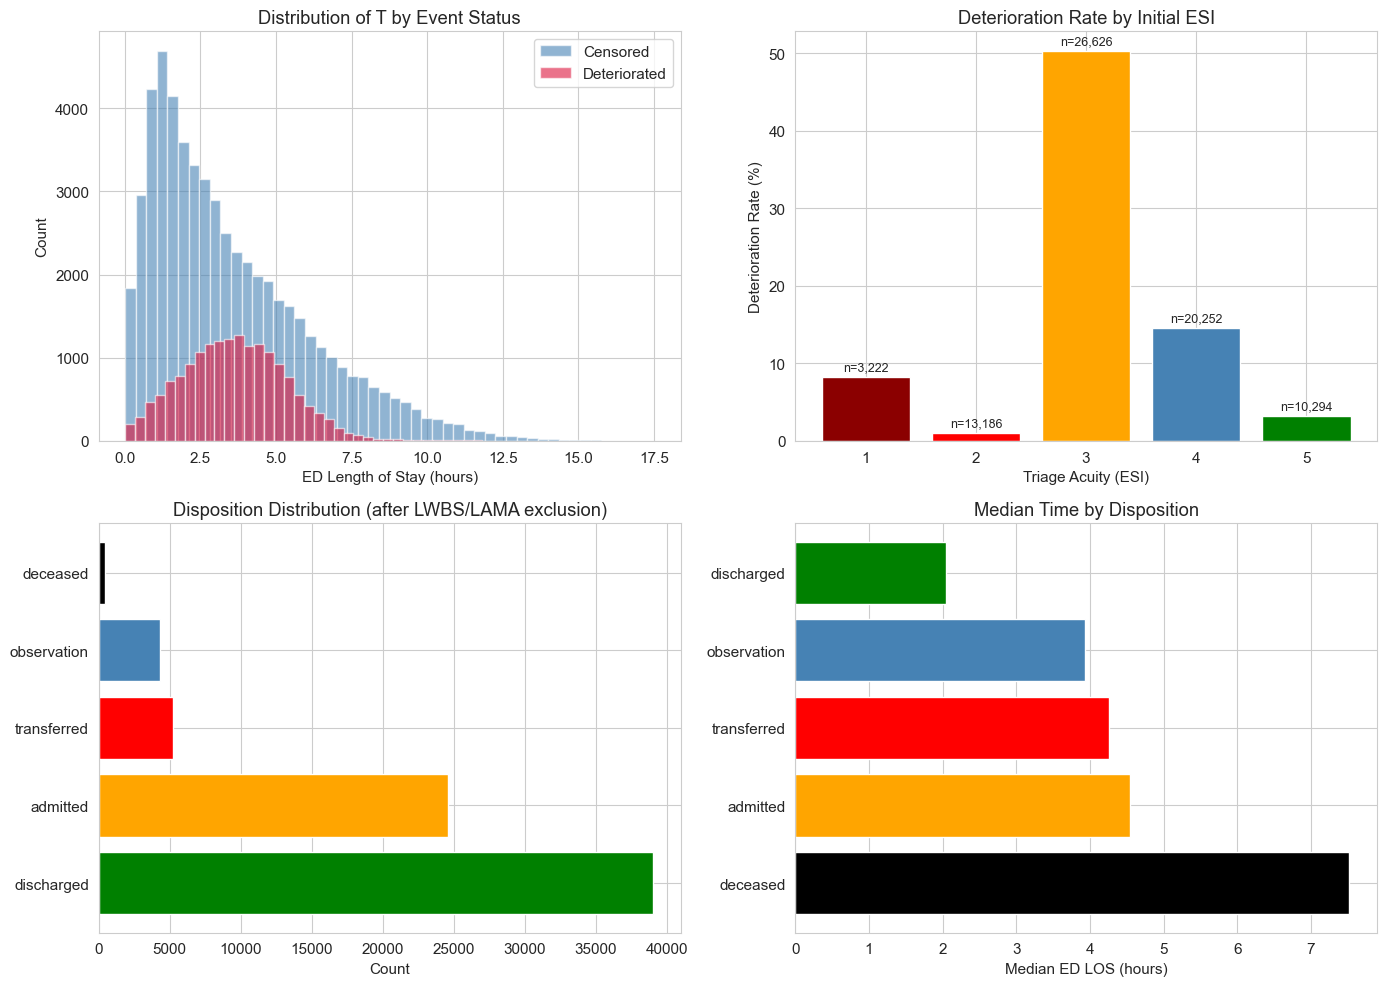

In [5]:
if not df_triage.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # (a) Distribution of T by event status
    ax = axes[0, 0]
    df_surv[df_surv['E'] == 0]['T'].hist(bins=50, alpha=0.6, label='Censored', ax=ax, color='steelblue')
    df_surv[df_surv['E'] == 1]['T'].hist(bins=50, alpha=0.6, label='Deteriorated', ax=ax, color='crimson')
    ax.set_xlabel('ED Length of Stay (hours)')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of T by Event Status')
    ax.legend()
    
    # (b) Event rate by triage acuity
    ax = axes[0, 1]
    event_by_acuity = df_surv.groupby('triage_acuity')['E'].agg(['mean', 'count'])
    bars = ax.bar(event_by_acuity.index, event_by_acuity['mean'] * 100, 
                  color=['darkred', 'red', 'orange', 'steelblue', 'green'])
    ax.set_xlabel('Triage Acuity (ESI)')
    ax.set_ylabel('Deterioration Rate (%)')
    ax.set_title('Deterioration Rate by Initial ESI')
    for bar, count in zip(bars, event_by_acuity['count']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'n={count:,}', ha='center', va='bottom', fontsize=9)
    
    # (c) Disposition breakdown
    ax = axes[1, 0]
    disp_counts = df_surv['disposition'].value_counts()
    colors = {'discharged': 'green', 'admitted': 'orange', 'observation': 'steelblue',
              'transferred': 'red', 'deceased': 'black'}
    ax.barh(disp_counts.index, disp_counts.values, 
            color=[colors.get(d, 'gray') for d in disp_counts.index])
    ax.set_xlabel('Count')
    ax.set_title('Disposition Distribution (after LWBS/LAMA exclusion)')
    
    # (d) Median T by disposition
    ax = axes[1, 1]
    median_t = df_surv.groupby('disposition')['T'].median().sort_values(ascending=False)
    ax.barh(median_t.index, median_t.values,
            color=[colors.get(d, 'gray') for d in median_t.index])
    ax.set_xlabel('Median ED LOS (hours)')
    ax.set_title('Median Time by Disposition')
    
    plt.tight_layout()
    plt.savefig(CONFIG['output_dir'] + 'event_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

**Key observations from the event distribution analysis:**

**Top-left (T distribution):** Both censored and deteriorated patients follow a right-skewed distribution, with most ED stays lasting 1-5 hours. Deteriorated patients (red) tend to have longer stays, peaking around 3-4 hours, while censored patients (blue) cluster earlier - consistent with lower-acuity patients being discharged quickly.

**Top-right (Deterioration rate by ESI):** ESI 3 dominates with ~50% deterioration rate - these are the "urgent" patients most likely to be undertriaged. ESI 4 and 5 show lower but non-negligible rates (~15% and ~3%), confirming that unexpected admissions do occur even among low-acuity patients. **ESI 1-2 rates are low by design: only deaths count as deterioration for them**, since admission is their expected trajectory.

**Bottom-left (Disposition counts):** The dataset is dominated by discharges (~40k) and admissions (~25k), with very few deaths. This class imbalance means our survival models will be learning primarily from the admitted-vs-discharged contrast rather than from mortality events.

**Bottom-right (Median LOS by disposition):** Deceased patients have the longest median stay (~7.5h), followed by admitted (~4.5h) and transferred (~4.5h). Discharged patients leave fastest (~1.5h). This confirms that `ed_los_hours` carries signal - adverse outcomes are associated with longer stays - but also highlights the caveat that longer T doesn't necessarily mean later deterioration.


### 1.3 - Define covariates (features available at triage time)

In [6]:

# Vital signs
VITAL_COLS = [
    'systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate',
    'temperature_c', 'spo2', 'mean_arterial_pressure', 'pulse_pressure',
    'shock_index',
]

# Composite scores
SCORE_COLS = ['news2_score', 'gcs_total', 'pain_score', 'bmi']

# Demographics & context
NUMERIC_COLS = [
    'age', 'arrival_hour', 'num_prior_ed_visits_12m',
    'num_prior_admissions_12m', 'num_active_medications', 'num_comorbidities',
]

CATEGORICAL_COLS = [
    'sex', 'age_group', 'arrival_mode', 'shift', 'arrival_season',
    'insurance_type', 'pain_location', 'mental_status_triage',
]

# Comorbidity flags (binary)
HX_COLS = [c for c in df_surv.columns if c.startswith('hx_')]

# All feature columns (no outcome leakage)
ALL_NUMERIC = VITAL_COLS + SCORE_COLS + NUMERIC_COLS
ALL_FEATURES = ALL_NUMERIC + CATEGORICAL_COLS + HX_COLS

# Check which columns actually exist in our data
available_features = [c for c in ALL_FEATURES if c in df_surv.columns]
missing_features = [c for c in ALL_FEATURES if c not in df_surv.columns]

print(f"Available features: {len(available_features)}")
print(f"Missing features ({len(missing_features)}): {missing_features}")
print(f"\nNumeric: {len([c for c in ALL_NUMERIC if c in df_surv.columns])}")
print(f"Categorical: {len([c for c in CATEGORICAL_COLS if c in df_surv.columns])}")
print(f"Comorbidities: {len([c for c in HX_COLS if c in df_surv.columns])}")

Available features: 52
Missing features (0): []

Numeric: 19
Categorical: 8
Comorbidities: 25


### 1.4 - Preprocessing pipeline

In [7]:
def preprocess_survival_data(df, numeric_cols, categorical_cols, hx_cols):
    """
    Preprocess covariates for survival modeling.
    
    - Impute missing vitals with median
    - Encode categoricals (ordinal for trees, one-hot for linear/neural models)
    - Standardize numerics for neural models
    
    Returns:
        X_processed (DataFrame), feature_names (list)
    """
    df = df.copy()
    
    # --- Numeric imputation (median) ---
    num_available = [c for c in numeric_cols if c in df.columns]
    for col in num_available:
        if df[col].isna().any():
            median_val = df[col].median()
            n_missing = df[col].isna().sum()
            df[col] = df[col].fillna(median_val)
            print(f"  Imputed {col}: {n_missing} missing -> median={median_val:.2f}")
    
    # --- Binary comorbidity columns: fill NaN with 0 ---
    hx_available = [c for c in hx_cols if c in df.columns]
    for col in hx_available:
        df[col] = df[col].fillna(0).astype(int)
    
    # --- Categorical encoding (one-hot) ---
    cat_available = [c for c in categorical_cols if c in df.columns]
    if cat_available:
        df_encoded = pd.get_dummies(df[cat_available], prefix=cat_available, 
                                     drop_first=True, dtype=int)
        # Merge back
        df = pd.concat([df.drop(columns=cat_available), df_encoded], axis=1)
    
    # Collect all feature columns
    encoded_cat_cols = [c for c in df.columns if any(c.startswith(p + '_') for p in cat_available)]
    feature_cols = num_available + hx_available + encoded_cat_cols
    
    return df, feature_cols

# Preprocess
print("Preprocessing covariates")
df_surv_processed, FEATURE_COLS = preprocess_survival_data(
    df_surv, ALL_NUMERIC, CATEGORICAL_COLS, HX_COLS
)
print(f"\nTotal features after encoding: {len(FEATURE_COLS)}")

Preprocessing covariates
  Imputed systolic_bp: 3667 missing -> median=122.60
  Imputed diastolic_bp: 3667 missing -> median=75.10
  Imputed respiratory_rate: 2732 missing -> median=17.40
  Imputed temperature_c: 513 missing -> median=37.50
  Imputed mean_arterial_pressure: 3667 missing -> median=91.50
  Imputed pulse_pressure: 3667 missing -> median=47.00
  Imputed shock_index: 3667 missing -> median=0.73

Total features after encoding: 76


### 1.5 - Train / Validation / Test split

Stratified split by event indicator to maintain event rate across splits

In [8]:
# First: 80% train+val, 20% test
df_trainval, df_test = train_test_split(
    df_surv_processed, test_size=CONFIG['test_size'],
    stratify=df_surv_processed['E'], random_state=SEED
)

# Then: from train+val, split into train and validation
df_train, df_val = train_test_split(
    df_trainval, test_size=CONFIG['val_size'],
    stratify=df_trainval['E'], random_state=SEED
)

print(f"Train: {len(df_train):,} ({df_train['E'].mean()*100:.1f}% events)")
print(f"Val:   {len(df_val):,} ({df_val['E'].mean()*100:.1f}% events)")
print(f"Test:  {len(df_test):,} ({df_test['E'].mean()*100:.1f}% events)")

# Standardize numeric features using TRAINING statistics only
scaler = StandardScaler()
num_available = [c for c in ALL_NUMERIC if c in FEATURE_COLS]

scaler.fit(df_train[num_available])
for split_df in [df_train, df_val, df_test]:
    split_df[num_available] = scaler.transform(split_df[num_available])

print("\nNumeric features standardized (fit on train only).")

Train: 50,034 (23.2% events)
Val:   8,830 (23.2% events)
Test:  14,716 (23.2% events)

Numeric features standardized (fit on train only).


### 1.6 - Prepare data structures for different libraries

In [9]:
def make_sksurv_y(df):
    """Create scikit-survival structured array from dataframe."""
    return Surv.from_dataframe('E', 'T', df.astype({'E': bool}))

def make_pycox_data(df, feature_cols):
    """Prepare numpy arrays for pycox models."""
    x = df[feature_cols].values.astype('float32')
    t = df['T'].values.astype('float32')
    e = df['E'].values.astype('float32')
    return x, t, e

# scikit-survival format
y_train_surv = make_sksurv_y(df_train)
y_val_surv = make_sksurv_y(df_val)
y_test_surv = make_sksurv_y(df_test)

X_train = df_train[FEATURE_COLS].values
X_val = df_val[FEATURE_COLS].values
X_test = df_test[FEATURE_COLS].values

# pycox format
x_train_pc, t_train_pc, e_train_pc = make_pycox_data(df_train, FEATURE_COLS)
x_val_pc, t_val_pc, e_val_pc = make_pycox_data(df_val, FEATURE_COLS)
x_test_pc, t_test_pc, e_test_pc = make_pycox_data(df_test, FEATURE_COLS)

print("Data structures prepared for all libraries.")
print(f"Feature matrix shape: {X_train.shape}")

Data structures prepared for all libraries.
Feature matrix shape: (50034, 76)


## Section 2: Exploratory Survival Analysis

Before fitting any model, we explore the survival landscape using **non-parametric estimators** - methods that make no assumptions about the shape of the underlying distributions. They let the data speak for itself.

### Kaplan-Meier Estimator

The Kaplan-Meier (KM) estimator is the most common way to estimate the survival function S(t) from observed data. It works by computing the probability of surviving past each observed event time, then chaining these probabilities together.

At each time $t_i$ where at least one event occurs, we observe:
- $d_i$: the number of patients who deteriorated at time $t_i$
- $n_i$: the number of patients still "at risk" just before $t_i$ (i.e., they hadn't deteriorated or been censored yet)

The KM estimate is:

$$\hat{S}(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$$

Intuitively: at each event time, we compute the fraction of at-risk patients who survived that moment, and multiply all these fractions together. Censored patients contribute to $n_i$ (they were still at risk before leaving), but not to $d_i$ - this is how KM handles incomplete observations without discarding them.

### Nelson-Aalen Estimator

While KM estimates S(t) directly, the Nelson-Aalen estimator targets the **cumulative hazard function** $H(t)$, which is the integral of the hazard rate up to time t:

$$\hat{H}(t) = \sum_{t_i \leq t} \frac{d_i}{n_i}$$

The relationship between cumulative hazard and survival is: $S(t) = e^{-H(t)}$, so they contain the same information - but H(t) is more useful for understanding the **shape** of the hazard:

- If H(t) is a **straight line** -> the hazard rate is constant over time (Exponential model would fit well)
- If H(t) is **convex** (curves upward) -> the hazard is increasing - risk gets worse the longer you wait
- If H(t) is **concave** (curves and flattens) -> the hazard is decreasing - the highest risk is early on
- If H(t) has an **S-shape** (convex then concave) -> the hazard first increases then decreases - a peak risk window exists

This is why we plot Nelson-Aalen before choosing parametric models: it tells us which distributional assumptions are reasonable.

### Log-Rank Test

The log-rank test compares survival curves between two or more groups (e.g., ESI 3 vs ESI 4 vs ESI 5) to determine if the differences are statistically significant or could be due to chance.

For each event time $t_i$, it compares the **observed** number of events in each group against the **expected** number if the groups had identical survival. The test statistic is:

$$\chi^2 = \sum_{g=1}^{G} \frac{(O_g - E_g)^2}{E_g}$$

where $O_g$ is the total observed events in group $g$, and $E_g$ is the expected count under the null hypothesis of equal survival. This follows a chi-squared distribution with $G-1$ degrees of freedom.

A small p-value (e.g., < 0.05) means the groups have significantly different survival - which in our context means that the stratification variable (ESI level, NEWS2 band, age group...) meaningfully separates patients by deterioration risk.

### 2.1 - Overall Kaplan-Meier curve

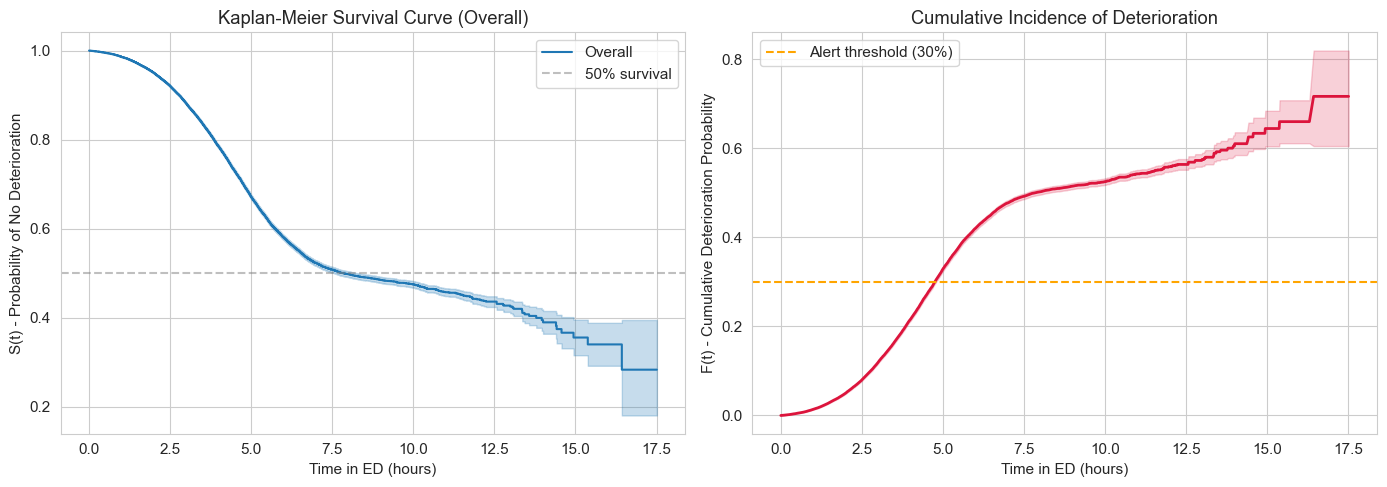

Median time to deterioration (overall): 7.85 hours


In [10]:
kmf = KaplanMeierFitter()
kmf.fit(df_surv['T'], event_observed=df_surv['E'], label='Overall')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival function
ax = axes[0]
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_xlabel('Time in ED (hours)')
ax.set_ylabel('S(t) - Probability of No Deterioration')
ax.set_title('Kaplan-Meier Survival Curve (Overall)')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% survival')
ax.legend()

# Cumulative incidence (1 - S(t))
ax = axes[1]
ax.plot(kmf.timeline, 1 - kmf.survival_function_['Overall'], color='crimson', linewidth=2)
ax.fill_between(kmf.timeline, 
                1 - kmf.confidence_interval_['Overall_upper_0.95'],
                1 - kmf.confidence_interval_['Overall_lower_0.95'],
                alpha=0.2, color='crimson')
ax.set_xlabel('Time in ED (hours)')
ax.set_ylabel('F(t) - Cumulative Deterioration Probability')
ax.set_title('Cumulative Incidence of Deterioration')
ax.axhline(y=CONFIG['alert_risk_threshold'], color='orange', linestyle='--', 
           label=f'Alert threshold ({CONFIG["alert_risk_threshold"]*100:.0f}%)')
ax.legend()

plt.tight_layout()
plt.savefig(CONFIG['output_dir'] + 'km_overall.png', dpi=150, bbox_inches='tight')
plt.show()

# Median survival time
median_surv = kmf.median_survival_time_
print(f"Median time to deterioration (overall): {median_surv:.2f} hours")

**Key observations:**

**Left panel - Survival curve S(t):** The curve drops steeply in the first 6 hours, falling from 1.0 to ~0.55, meaning that nearly half of all deterioration events occur within this window. The median survival time (where S(t) crosses the 50% dashed line) is approximately 6-7 hours - after this point, more than half of the at-risk patients have already experienced the event. After ~10 hours the curve flattens, with wide confidence intervals due to fewer patients remaining under observation.

**Right panel - Cumulative incidence F(t) = 1 - S(t):** This is the "risk view" - the same information, but framed as the probability of deterioration. The 30% alert threshold (orange dashed line) is crossed around hour 4-5, suggesting that this could be a reasonable default monitoring window: if a patient has been waiting more than ~5 hours, the overall population-level risk of unexpected escalation exceeds 30%. However, this is the **average across all patients** - personalized models (Sections 3-4) will produce individual thresholds that are much earlier for high-risk patients and much later for low-risk ones.

**Clinical takeaway:** The first 5 hours are the critical monitoring window. A decision support system should focus its attention here - this is when the majority of undertriage cases reveal themselves through adverse outcomes.


### 2.2 - Kaplan-Meier stratified by Triage Acuity (ESI)


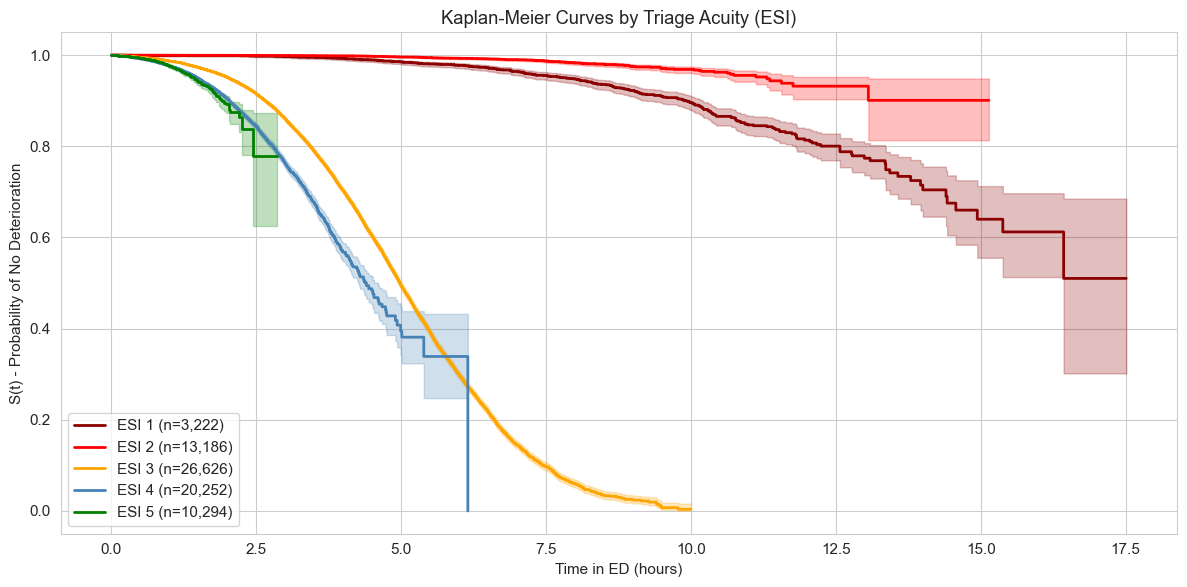

Multivariate log-rank test: statistic=17497.13, p=0.00e+00


In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
colors_esi = {1: 'darkred', 2: 'red', 3: 'orange', 4: 'steelblue', 5: 'green'}

for esi in sorted(df_surv['triage_acuity'].unique()):
    mask = df_surv['triage_acuity'] == esi
    kmf_esi = KaplanMeierFitter()
    kmf_esi.fit(df_surv.loc[mask, 'T'], event_observed=df_surv.loc[mask, 'E'],
                label=f'ESI {esi} (n={mask.sum():,})')
    kmf_esi.plot_survival_function(ax=ax, color=colors_esi.get(esi, 'gray'), linewidth=2)

ax.set_xlabel('Time in ED (hours)')
ax.set_ylabel('S(t) - Probability of No Deterioration')
ax.set_title('Kaplan-Meier Curves by Triage Acuity (ESI)')
ax.legend(loc='lower left')

plt.tight_layout()
plt.savefig(CONFIG['output_dir'] + 'km_by_esi.png', dpi=150, bbox_inches='tight')
plt.show()

# Log-rank test across all ESI groups
result = multivariate_logrank_test(df_surv['T'], df_surv['triage_acuity'], df_surv['E'])
print(f"Multivariate log-rank test: statistic={result.test_statistic:.2f}, p={result.p_value:.2e}")

ESI 3 (orange) shows the steepest decline, reaching S(t) ≈ 0 by hour 10, meaning nearly all ESI 3 patients who will experience an unexpected escalation do so within this window. ESI 4 (blue) and ESI 5 (green) drop fast in the first 2-3 hours and then run out of patients at risk (short ED stays, most get discharged quickly). ESI 1 (dark red) and ESI 2 (red) remain near 1.0 for most of the observation period.

**Why do ESI 1-2 patients appear to have the "best" survival curves, even though they are the sickest?** This is not a paradox, it is a direct consequence of our event definition. We defined deterioration as an *unexpected* severity escalation. For ESI 1-2 patients, admission to the hospital is the **expected and planned outcome**, a critically ill patient who gets admitted is following the correct clinical pathway, so our model does not count this as deterioration. The only event that counts for them is death, which is rare. Conversely, ESI 3-5 patients were triaged as "not severely ill", so any admission or transfer signals that the initial assessment missed something. Their curves drop rapidly because every unexpected admission counts as an event. In summary: the curves are not showing "who is sicker", they are showing **"who was triaged correctly."**

### 2.3 - KM stratified by NEWS2 score bands

NEWS2 risk bands: 0-4 = Low, 5-6 = Medium, >= 7 = High

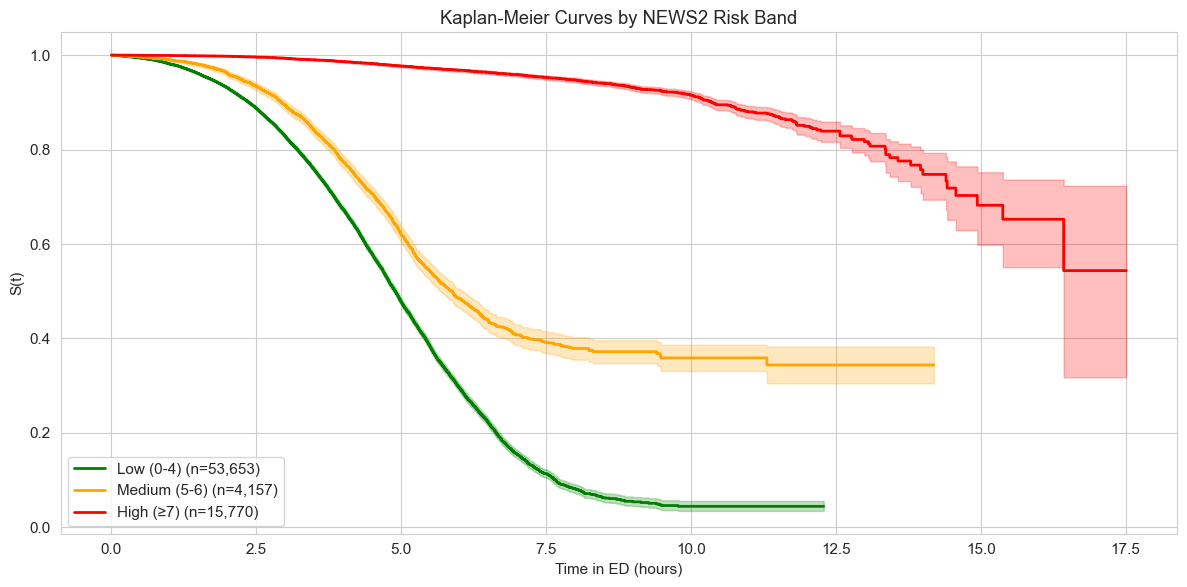

In [12]:
if 'news2_score' in df_surv.columns and df_surv['news2_score'].notna().any():
    # Use unscaled original data for binning
    news2_raw = df_triage.loc[df_surv.index, 'news2_score'] if 'news2_score' in df_triage.columns else df_surv['news2_score']
    
    # If data is standardized, we need the original values
    # For display purposes, we create bins from the original dataset
    df_surv_temp = df_surv.copy()
    if 'news2_score' in df_triage.columns:
        df_surv_temp['news2_raw'] = df_triage.loc[df_surv.index, 'news2_score'].values
    else:
        df_surv_temp['news2_raw'] = df_surv['news2_score']
    
    df_surv_temp['news2_band'] = pd.cut(
        df_surv_temp['news2_raw'], 
        bins=[-1, 4, 6, 100], 
        labels=['Low (0-4)', 'Medium (5-6)', 'High (≥7)']
    )
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors_news2 = {'Low (0-4)': 'green', 'Medium (5-6)': 'orange', 'High (≥7)': 'red'}
    
    for band in ['Low (0-4)', 'Medium (5-6)', 'High (≥7)']:
        mask = df_surv_temp['news2_band'] == band
        if mask.sum() > 0:
            kmf_n = KaplanMeierFitter()
            kmf_n.fit(df_surv_temp.loc[mask, 'T'], event_observed=df_surv_temp.loc[mask, 'E'],
                      label=f'{band} (n={mask.sum():,})')
            kmf_n.plot_survival_function(ax=ax, color=colors_news2[band], linewidth=2)
    
    ax.set_xlabel('Time in ED (hours)')
    ax.set_ylabel('S(t)')
    ax.set_title('Kaplan-Meier Curves by NEWS2 Risk Band')
    ax.legend(loc='lower left')
    plt.tight_layout()
    plt.savefig(CONFIG['output_dir'] + 'km_by_news2.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("NEWS2 score not available - skipping this analysis.")

The pattern is conceptually similar but stratified by a different clinical score. Low NEWS2 (0-4, green, n=53,653) drops fastest and most steeply, reaching S(t) ≈ 0.05 by hour 10. Medium NEWS2 (5-6, orange, n=4,157) follows a similar trajectory but slightly delayed, flattening around S(t) ≈ 0.35 after hour 8. High NEWS2 (≥7, red, n=15,770) stays near the top, declining slowly and remaining above S(t) ≈ 0.6 even at hour 15.

**Why does high NEWS2, indicating worse physiological status, correspond to higher survival?** The same logic applies here. NEWS2 is correlated with ESI: patients with high NEWS2 scores tend to be triaged as ESI 1-2, where admission is already anticipated. Their high score means the triage system *correctly identified* them as critical, so their outcome matches the expectation, no undertriage, no "event" in our framework. Patients with low NEWS2 were assessed as physiologically stable, but when they unexpectedly end up admitted, that mismatch between a reassuring NEWS2 score and an adverse outcome is exactly what our model flags as deterioration. 
This also has a practical implication: **NEWS2 alone, used as a simple threshold, would flag the *wrong* patients for our purpose, it would flag those already correctly identified as critical, while missing the undertriage cases.** This motivates the use of more sophisticated survival models that combine NEWS2 with other features to identify truly unexpected escalations.

### 2.4 - KM stratified by age group and arrival mode

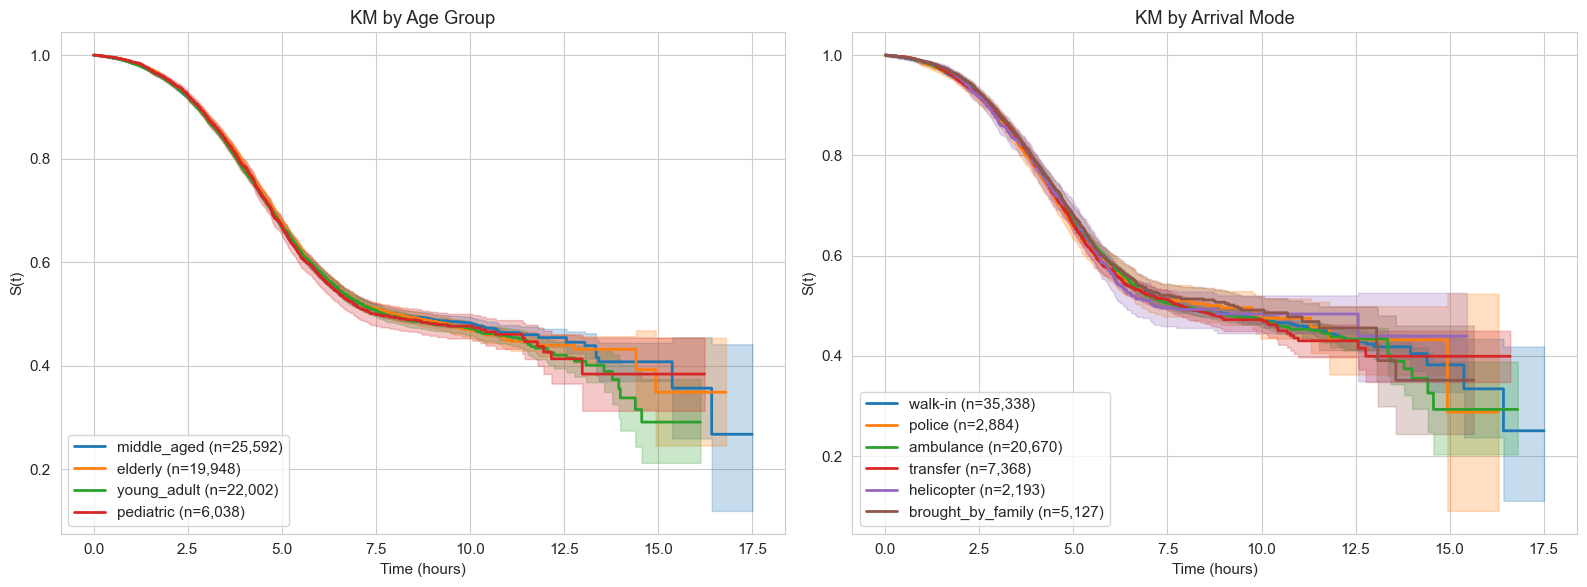

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By age group
ax = axes[0]
if 'age_group' in df_surv.columns:
    for group in df_surv['age_group'].dropna().unique():
        mask = df_surv['age_group'] == group
        kmf_ag = KaplanMeierFitter()
        kmf_ag.fit(df_surv.loc[mask, 'T'], event_observed=df_surv.loc[mask, 'E'],
                   label=f'{group} (n={mask.sum():,})')
        kmf_ag.plot_survival_function(ax=ax, linewidth=2)
    ax.set_title('KM by Age Group')
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('S(t)')
    ax.legend(loc='lower left')

# By arrival mode
ax = axes[1]
if 'arrival_mode' in df_surv.columns:
    for mode in df_surv['arrival_mode'].dropna().unique():
        mask = df_surv['arrival_mode'] == mode
        if mask.sum() > 50:  # skip tiny groups
            kmf_am = KaplanMeierFitter()
            kmf_am.fit(df_surv.loc[mask, 'T'], event_observed=df_surv.loc[mask, 'E'],
                       label=f'{mode} (n={mask.sum():,})')
            kmf_am.plot_survival_function(ax=ax, linewidth=2)
    ax.set_title('KM by Arrival Mode')
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('S(t)')
    ax.legend(loc='lower left')

plt.tight_layout()
plt.savefig(CONFIG['output_dir'] + 'km_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Neither age group nor arrival mode alone are strong predictors of unexpected deterioration. The real discriminating power comes from the clinical variables (ESI, NEWS2, vitals) seen in the previous plots.

### 2.5 - Nelson-Aalen cumulative hazard (hazard shape analysis)

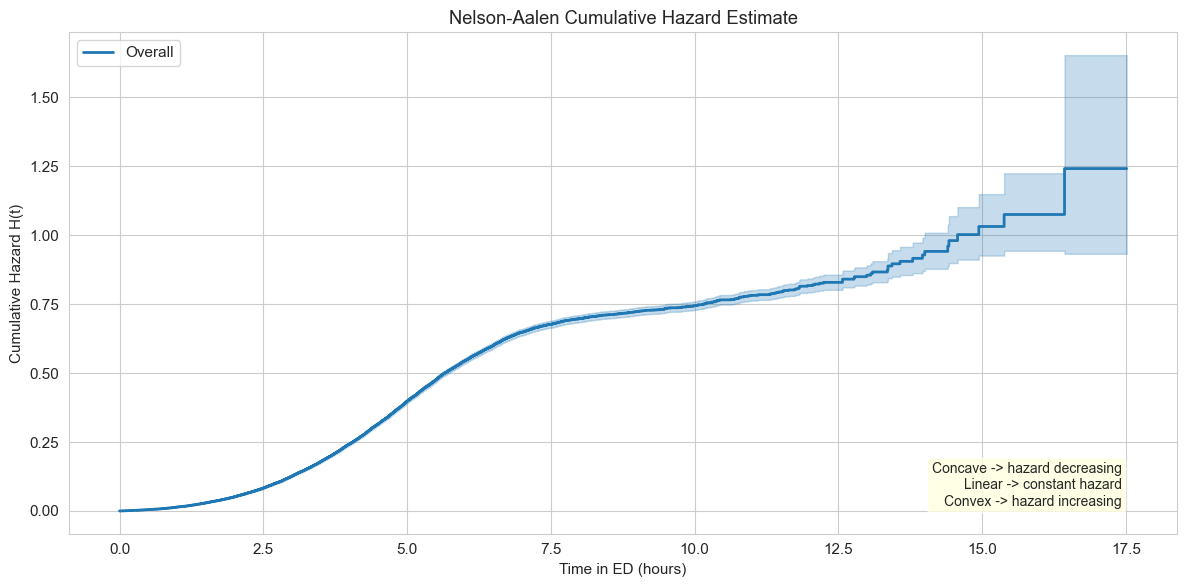

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
naf = NelsonAalenFitter()
naf.fit(df_surv['T'], event_observed=df_surv['E'], label='Overall')
naf.plot_cumulative_hazard(ax=ax, linewidth=2)

ax.set_xlabel('Time in ED (hours)')
ax.set_ylabel('Cumulative Hazard H(t)')
ax.set_title('Nelson-Aalen Cumulative Hazard Estimate')

# Interpretation helper
ax.annotate(
    'Concave -> hazard decreasing\nLinear -> constant hazard\nConvex -> hazard increasing',
    xy=(0.95, 0.05), xycoords='axes fraction', fontsize=10,
    ha='right', va='bottom',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()
plt.savefig(CONFIG['output_dir'] + 'nelson_aalen.png', dpi=150, bbox_inches='tight')
plt.show()

The curve shows a clear **S-shape**: convex (accelerating) from hour 0 to ~7, then concave (decelerating) from hour 7 onward. This means the instantaneous hazard rate **increases** during the first 7 hours, the longer a patient waits in this window, the higher the risk of deterioration at that moment, and then **decreases** after hour 7, as the remaining patients are likely stable. After hour 12, the curve becomes stepwise and noisy due to few patients remaining, with wide confidence intervals.

**Implication for model selection:** The non-monotone hazard (rises then falls) rules out simple Exponential (constant hazard) and makes Weibull a poor fit (monotone only). The **Log-Logistic** distribution, which allows a bell-shaped hazard, is the best parametric candidate. This also justifies **DeepHit and **Cox-Time**, which make no assumptions on hazard shape.**

## Section 3: Classical Survival Models

We start with interpretable classical models:
1. **Cox Proportional Hazards**: semi-parametric, estimates hazard ratios
2. **Weibull AFT**: parametric, assumes Weibull-distributed survival times
3. **Log-Logistic AFT**: parametric, allows non-monotone hazard functions

These provide a solid baseline and clinical interpretability (hazard ratios, p-values).

### 3.1 - Cox Proportional Hazards (lifelines)

The Cox PH model (Cox, 1972) is the most widely used survival model. It models the hazard function as:

$$h(t \mid X) = h_0(t) \cdot \exp(\beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p)$$

where:
- $h_0(t)$ is the **baseline hazard** - the hazard for a "reference" patient with all covariates at zero. This is left completely unspecified (hence "semi-parametric").
- $\exp(\beta^T X)$ is the **relative risk** - how much the patient's covariates multiply the baseline hazard.

The model is called "proportional hazards" because the hazard ratio between any two patients is **constant over time**:

$$\frac{h(t \mid X_A)}{h(t \mid X_B)} = \frac{\exp(\beta^T X_A)}{\exp(\beta^T X_B)} = \exp\left(\beta^T (X_A - X_B)\right)$$

This ratio does not depend on $t$ - if patient A has twice the hazard of patient B at hour 1, they still have twice the hazard at hour 6. This is a strong assumption that we will test with Schoenfeld residuals in the next cell.

Each coefficient $\beta_j$ has a direct clinical interpretation: $\exp(\beta_j)$ is the **hazard ratio** - how much the risk is multiplied for a one-unit increase in feature $X_j$. For example, $\exp(\beta) = 1.5$ means that feature increases the hazard by 50%. Values below 1 are protective.

We apply L2 regularization (`penalizer=0.01`) to stabilize coefficient estimates when features are correlated (e.g., systolic BP and MAP).


In [15]:
# Prepare data for lifelines (needs DataFrame with T, E, and covariates)
# Use unscaled data for Cox PH (lifelines handles scaling internally)
cox_cols = [c for c in FEATURE_COLS if c in df_train.columns]

# Create lifelines-compatible DataFrame
df_cox_train = df_train[['T', 'E'] + cox_cols].copy()
df_cox_val = df_val[['T', 'E'] + cox_cols].copy()
df_cox_test = df_test[['T', 'E'] + cox_cols].copy()

# Fit Cox PH
cph = CoxPHFitter(penalizer=0.01)  # L2 regularization for stability
cph.fit(df_cox_train, duration_col='T', event_col='E', show_progress=False)

# Summary - top 20 most significant covariates
print("Cox PH Model - Top 20 Covariates by Significance")
print("=" * 80)
summary = cph.summary.sort_values('p')
print(summary.head(20)[['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%']])

# Concordance index
c_index_train = cph.concordance_index_
print(f"\nCox PH C-index (train): {c_index_train:.4f}")

Cox PH Model - Top 20 Covariates by Significance
                                       coef  exp(coef)  se(coef)  \
covariate                                                          
gcs_total                          0.614812   1.849309  0.024018   
news2_score                       -0.585984   0.556558  0.026407   
pain_score                        -0.093015   0.911180  0.009737   
num_prior_ed_visits_12m           -0.087555   0.916168  0.012295   
temperature_c                     -0.080871   0.922313  0.011815   
mental_status_triage_alert         0.157842   1.170981  0.031761   
respiratory_rate                  -0.053990   0.947441  0.013997   
mental_status_triage_drowsy       -0.146490   0.863734  0.041173   
hx_substance_use_disorder         -0.063971   0.938032  0.026204   
pain_location_multiple             0.079811   1.083083  0.036187   
hx_hypothyroidism                 -0.058216   0.943446  0.026582   
bmi                               -0.018572   0.981600  0.009159   

**Cox PH Results and Observations:**

The model achieves a **C-index of 0.718** on the training set. The C-index (Concordance Index) measures how well the model ranks patients by risk: it takes all pairs of patients and checks whether the one predicted as higher-risk actually deteriorated first. A C-index of 0.5 means random guessing, 1.0 means perfect ranking. Our value of 0.718 indicates reasonable discriminative ability, the model correctly ranks patients about 72% of the time.

**Top risk factors (higher hazard = faster deterioration):**
- `gcs_total` (HR = 1.85, p ≈ 0): the strongest predictor. GCS (Glasgow Coma Scale) is a clinical score from 3 to 15 that measures the patient's level of consciousness, 15 means fully alert, 3 means deep coma. A higher GCS, meaning a more alert patient, is associated with *higher* hazard. This seems counterintuitive, but recall our event definition: alert patients (high GCS) are more likely to be triaged as ESI 3-5, where any admission counts as unexpected escalation. Patients with low GCS are triaged as ESI 1-2, where admission is expected and not counted as an event.
- `mental_status_triage_alert` (HR = 1.17): same logic, alert patients are the ones who can be "surprisingly" admitted.

**Top protective factors (lower hazard = slower deterioration):**
- `news2_score` (HR = 0.56, p ≈ 0): higher NEWS2 *reduces* the hazard. Consistent with our framework, high NEWS2 patients are triaged as ESI 1-2, where admission is expected and not counted as an event.
- `pain_score` (HR = 0.91), `temperature_c` (HR = 0.92), `num_prior_ed_visits_12m` (HR = 0.92): all mildly protective, suggesting that more obviously symptomatic patients get correctly triaged, reducing the undertriage rate.

**Important note:** Several features (diastolic_bp, spo2, age, liver disease, immunosuppression) have p-values > 0.05, not statistically significant at conventional thresholds. The model is dominated by `gcs_total` and `news2_score`, which together encode most of the information about whether the triage assessment matched the actual outcome.

### 3.2 - Test Proportional Hazards assumption

In [16]:
print("Testing Proportional Hazards Assumption (Schoenfeld residuals)")
print("=" * 80)

# This tests whether hazard ratios are constant over time
# If p < 0.05, the PH assumption is violated for that covariate
try:
    ph_test = cph.check_assumptions(df_cox_train, p_value_threshold=0.05, 
                                     show_plots=False)
    # If we get here without exception, PH assumption holds
    print("\nPH assumption not rejected for any covariate at p=0.05 level.")
except Exception as e:
    print(f"\nPH assumption VIOLATED for some covariates (this is expected).")
    print("This justifies using non-proportional models (Cox-Time, DeepHit).")
    print(f"Details: {str(e)[:500]}")

Testing Proportional Hazards Assumption (Schoenfeld residuals)
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'heart_rate' failed the non-proportional test: p-value is 0.0225.

   Advice 1: the functional form of the variable 'heart_rate' might be incorrect. That is, there may
be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'heart_rate' using pd.cut, and then specify it in
`strata=['heart_rate', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'spo2' failed the non-proportional test: p-value is 0.0002.

   Advice 1: the functional form of the variable 'spo2' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional

**Results:**

The Schoenfeld residual test checks, for each covariate, whether its effect on risk stays constant over time (as Cox PH assumes) or changes. Out of all covariates, **12 violate the assumption** (p < 0.05):

- `gcs_total` and `news2_score` (p < 0.005): the two most important predictors have effects that **change over time**. For example, a low GCS (Glasgow Coma Scale) score may carry high risk in the first hours, but its predictive power fades as clinicians intervene and reassess the patient.
- `shock_index` (p < 0.005): the shock index (heart rate / systolic blood pressure, values above 0.9 suggest a shock state) measures hemodynamic instability, and its impact on risk changes between the early and late hours of the ED stay.
- `spo2`, `pain_score`, `heart_rate`: vital signs whose relationship with deterioration risk is not constant over time.
- Several binary variables (`hx_pregnant`, `hx_hypothyroidism`, `mental_status_triage` categories): their effect also varies with time.

**What this means in practice:** Cox PH assumes that if patient A has twice the risk of patient B at hour 1, they still have exactly twice the risk at hour 8. The data says this is not true, the risk ratio between patients shifts as time passes. The Cox PH model remains useful as an interpretable baseline (the hazard ratios tell us *which* features matter and *in which direction*), but its survival curve predictions are unreliable because of these violations.

This motivates the use of **non-proportional hazard models** in Section 4, particularly Cox-Time and DeepHit, which do not make this assumption.

---

### 3.3 - Weibull AFT Model

The Weibull Accelerated Failure Time (AFT) model is a **fully parametric** survival model, unlike Cox PH, it assumes a specific probability distribution for the survival times.

The core idea is simple: covariates **accelerate or decelerate** the time to event. A patient with risk factors doesn't have a higher hazard rate at every instant (like in Cox), instead, they experience the same process *faster*, as if time were compressed for them.

The model is formulated as:

$$\log(T) = \mu + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \sigma \cdot W$$

where:
- $T$ is the survival time
- $\mu$ is the intercept (baseline log-time)
- $\beta_j$ are the covariate effects: a positive $\beta_j$ means feature $X_j$ **extends** survival time (protective), a negative $\beta_j$ means it **shortens** survival time (risk factor). This is the **opposite sign convention** compared to Cox PH.
- $\sigma$ is the scale parameter, controlling the variance of the distribution
- $W$ follows a standard Extreme Value distribution, which makes $T$ follow a Weibull distribution

The Weibull distribution has a **shape parameter** that determines whether the hazard is monotonically increasing (shape > 1), monotonically decreasing (shape < 1), or constant (shape = 1, which reduces to the Exponential model). This is more flexible than Exponential but still limited: it cannot model the non-monotone, S-shaped hazard we observed in the Nelson-Aalen plot (Section 2). We include it as a parametric reference point and compare it via AIC with the Log-Logistic model, which can handle non-monotone hazards.

In [17]:
waft = WeibullAFTFitter(penalizer=0.01)
waft.fit(df_cox_train, duration_col='T', event_col='E', show_progress=False)

topx = 15
print(f"Weibull AFT - Top {topx} Covariates")
print("=" * 60)
waft_summary = waft.summary.sort_values('p')
print(waft_summary.head(topx)[['coef', 'exp(coef)', 'p']])
print(f"\nWeibull AIC: {waft.AIC_:.2f}")

Weibull AFT - Top 15 Covariates
                                         coef  exp(coef)              p
param   covariate                                                      
rho_    Intercept                    0.913309   2.492556   0.000000e+00
lambda_ Intercept                    2.023183   7.562361  2.202284e-173
        gcs_total                   -0.309775   0.733612  7.210069e-133
        news2_score                  0.306823   1.359101  1.867401e-111
        pain_score                   0.034056   1.034642   1.223729e-17
        num_prior_ed_visits_12m      0.031615   1.032120   6.622047e-10
        mental_status_triage_alert  -0.058511   0.943168   3.765693e-05
        temperature_c                0.019366   1.019554   1.106218e-04
        mental_status_triage_drowsy  0.058312   1.060046   1.200418e-03
        spo2                         0.016132   1.016263   1.444737e-02
        pain_location_multiple      -0.035796   0.964837   2.200834e-02
        pain_location_none      

**Weibull AFT Results:**

The same key predictors emerge: `gcs_total` and `news2_score` dominate, followed by `pain_score`, `num_prior_ed_visits_12m`, and `mental_status_triage`. The signs are **flipped** compared to Cox PH, this is expected because in AFT models, a positive coefficient means the feature *extends* survival time (protective), while in Cox a positive coefficient means it *increases* hazard (risk factor). For example, `news2_score` has a negative coefficient in Cox (lower hazard) and a positive coefficient here (longer time to event) - same clinical meaning, different mathematical convention.

The **shape parameter** `rho_` (exp(coef) = 2.49, meaning shape ≈ 2.49 > 1) indicates that the Weibull model estimates an **increasing hazard** over time. This partially captures the early phase we saw in the Nelson-Aalen plot (hours 0-7), but it cannot model the subsequent flattening - Weibull is forced to assume the hazard keeps increasing forever, which is unrealistic for our data. The AIC of 68,511.81 will serve as a reference to compare against the Log-Logistic model, which can capture the rise-then-fall pattern.

---

### 3.4 - Log-Logistic AFT Model

The Log-Logistic AFT model is another fully parametric survival model, structurally similar to the Weibull AFT:

$$\log(T) = \mu + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \sigma \cdot W$$

The only difference is the distribution of the error term $W$: here it follows a **standard Logistic distribution** instead of an Extreme Value, which makes $T$ follow a Log-Logistic distribution.

The critical advantage over Weibull is in the **hazard function shape**. While Weibull can only produce monotone hazards (always increasing or always decreasing), the Log-Logistic allows a **non-monotone, bell-shaped hazard**, the risk increases up to a peak and then decreases. This partially matches the pattern our Nelson-Aalen analysis revealed: the hazard rises steeply from hour 0 to ~7, then decelerates, but it does not drop to zero. The cumulative hazard continues to grow after hour 7, just at a slower rate, with occasional late spikes. The Log-Logistic bell-shaped hazard is therefore an approximation: it captures the initial acceleration and subsequent deceleration better than Weibull (which can only go in one direction), but it assumes the hazard eventually vanishes, which is not entirely realistic for our data.

If the Log-Logistic achieves a **lower AIC** than Weibull, it confirms that the non-monotone hazard is a better fit for our data.

In [18]:
llaft = LogLogisticAFTFitter(penalizer=0.01)
llaft.fit(df_cox_train, duration_col='T', event_col='E', show_progress=False)

print(f"Log-Logistic AFT - Top {topx} Covariates")
print("=" * 60)
llaft_summary = llaft.summary.sort_values('p')
print(llaft_summary.head(topx)[['coef', 'exp(coef)', 'p']])
print(f"\nLog-Logistic AIC: {llaft.AIC_:.2f}")

# Compare AIC
print(f"\n--- Parametric Model Comparison (Lower AIC = better) ---")
print(f"  Weibull AFT:     {waft.AIC_:.2f}")
print(f"  Log-Logistic AFT: {llaft.AIC_:.2f}")

Log-Logistic AFT - Top 15 Covariates
                                        coef  exp(coef)              p
param  covariate                                                      
beta_  Intercept                    1.060826   2.888757   0.000000e+00
alpha_ Intercept                    1.980336   7.245180  8.063420e-160
       news2_score                  0.344713   1.411584  2.741279e-124
       gcs_total                   -0.268393   0.764607  3.382219e-113
       pain_score                   0.036702   1.037384   1.997437e-16
       num_prior_ed_visits_12m      0.032495   1.033029   6.326772e-09
       mental_status_triage_alert  -0.067015   0.935181   1.573058e-05
       spo2                         0.026283   1.026631   2.190004e-04
       temperature_c                0.019112   1.019296   4.743606e-04
       mental_status_triage_drowsy  0.050856   1.052171   8.729569e-03
       bmi                          0.009765   1.009813   1.691117e-02
       shock_index                 -0.03

**Log-Logistic AFT Results:**

The same covariates dominate, `news2_score` and `gcs_total` remain the top two predictors, with sign conventions consistent with the Weibull model. The notable addition is `shock_index`, which appears significant here (p = 0.024) but wasn't in the Weibull top 15, suggesting the Log-Logistic captures some hemodynamic effects that the Weibull misses.

However, the AIC comparison is surprising: **Weibull (68,512) beats Log-Logistic (69,502)**. Despite the Log-Logistic's theoretical advantage of modeling non-monotone hazards, which we expected to fit our S-shaped Nelson-Aalen curve better, the data prefers the simpler Weibull. This may indicate that the non-monotone pattern is driven by heterogeneity across patient subgroups (each with a monotone hazard) rather than a truly non-monotone hazard at the individual level.

---

### 3.5 - Evaluate classical models on validation set


In [19]:
def evaluate_lifelines_model(model, df_test, model_name):
    """Evaluate a lifelines model on test data, return C-index."""
    # Predict partial hazard (or median survival time)
    if hasattr(model, 'predict_partial_hazard'):
        # Cox model: higher partial hazard = higher risk
        risk = model.predict_partial_hazard(df_test)
    elif hasattr(model, 'predict_median'):
        # AFT model: lower predicted median = higher risk
        risk = -model.predict_median(df_test)
    else:
        print(f"Cannot evaluate {model_name}")
        return None
    
    # Concordance index
    from lifelines.utils import concordance_index
    c_idx = concordance_index(df_test['T'], -risk, df_test['E'])
    return c_idx

results_classical = {}

for name, model in [('Cox PH', cph), ('Weibull AFT', waft), ('Log-Logistic AFT', llaft)]:
    c_val = evaluate_lifelines_model(model, df_cox_val, name)
    c_test = evaluate_lifelines_model(model, df_cox_test, name)
    results_classical[name] = {'C-index (val)': c_val, 'C-index (test)': c_test}
    print(f"{name:20s} | C-index val={c_val:.4f}  test={c_test:.4f}")

Cox PH               | C-index val=0.7172  test=0.7275
Weibull AFT          | C-index val=0.7160  test=0.7262
Log-Logistic AFT     | C-index val=0.7155  test=0.7255


**Classical Models, Validation and Test C-index:**

All three models perform almost identically, with C-index values clustered around 0.716-0.728. This tells us two things:

1. **The parametric assumption doesn't matter much here.** Whether we assume no distribution (Cox), a Weibull distribution, or a Log-Logistic distribution, the ranking of patients by risk is essentially the same. The models agree on *who* is at higher risk, they just disagree on the exact shape of the survival curve over time.

2. **There is a ceiling for linear models.** All three models assume a linear relationship between covariates and the log-hazard (or log-time). A C-index of ~0.72 suggests there is predictive signal, but also room for improvement, non-linear models (RSF, DeepHit) may capture interactions and complex patterns that linear models miss.

---

### 3.6 - Visualize Cox PH covariate effects

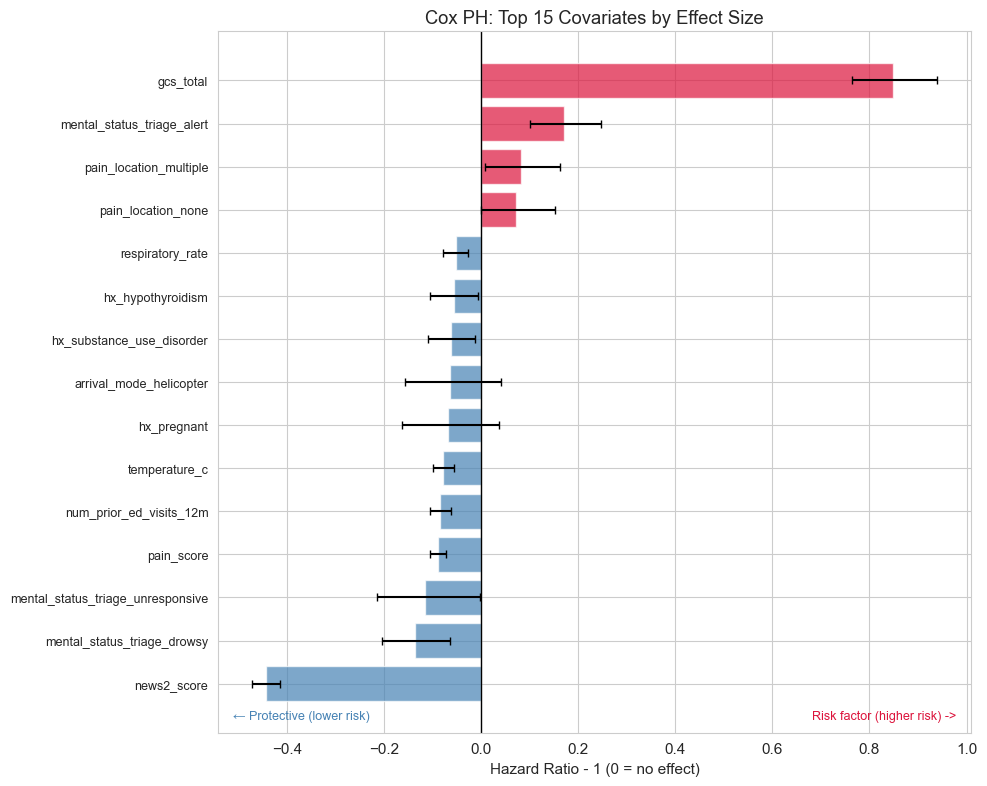

In [20]:
# Plot the hazard ratios for the top features
fig, ax = plt.subplots(figsize=(10, 8))

# Top 15 by absolute coefficient magnitude
top_features = cph.summary['coef'].abs().nlargest(15).index
top_summary = cph.summary.loc[top_features].sort_values('coef')

# Forest plot
y_pos = range(len(top_summary))
ax.barh(y_pos, top_summary['exp(coef)'] - 1, 
        xerr=[top_summary['exp(coef)'] - top_summary['exp(coef) lower 95%'],
              top_summary['exp(coef) upper 95%'] - top_summary['exp(coef)']],
        color=['crimson' if c > 0 else 'steelblue' for c in top_summary['coef']],
        alpha=0.7, capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_summary.index, fontsize=9)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Hazard Ratio - 1 (0 = no effect)')
ax.set_title('Cox PH: Top 15 Covariates by Effect Size')
ax.annotate('← Protective (lower risk)', xy=(0.02, 0.02), xycoords='axes fraction', fontsize=9, color='steelblue')
ax.annotate('Risk factor (higher risk) ->', xy=(0.98, 0.02), xycoords='axes fraction', 
            fontsize=9, color='crimson', ha='right')

plt.tight_layout()
plt.savefig(CONFIG['output_dir'] + 'cox_hazard_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

The plot confirms a clear two-group pattern. On the **risk side** (red), `gcs_total` dominates, its hazard ratio is by far the largest, meaning alert patients (high GCS) face the highest undertriage risk. `mental_status_triage_alert` reinforces this: being fully alert at triage increases the chance of being classified as low-acuity, and therefore of experiencing an "unexpected" admission. `pain_location_multiple` and `pain_location_none` are mild risk factors, diffuse or absent pain may be harder for triage nurses to classify correctly.

On the **"protective" side** (blue), `news2_score` has the strongest effect, a high NEWS2 means the patient was already flagged as physiologically compromised, reducing undertriage risk. `mental_status_drowsy` and `mental_status_unresponsive` are protective for the same reason: altered consciousness leads to higher ESI, making admission the expected outcome. The remaining protective factors (pain_score, temperature, prior ED visits) have small effects with tight confidence intervals, statistically significant but clinically modest.

**Overall pattern:** The model is essentially learning a proxy for "was this patient triaged correctly?" Features associated with appearing healthy at triage (high GCS, alert status) increase risk, while features that make illness obvious (high NEWS2, altered consciousness) are protective.

---

## Section 4: ML-Based Survival Models

Now we move to non-linear, tree-based and neural survival models:
1. **Random Survival Forest (RSF)**: ensemble of survival trees, no linearity assumption
2. **Gradient Boosted Survival Analysis (GBSA)**: boosted survival trees
3. **DeepSurv**: neural network with Cox PH loss (maintains PH assumption)
4. **Cox-Time**: relaxes PH by making the network time-dependent
5. **DeepHit**: learns the full survival distribution directly, no distributional assumptions

These models can capture non-linear feature interactions and non-proportional hazards. No tuning has been done on any models. 

---

### A note on model complexity and data limitations

All models in this section, regardless of their sophistication, learn from the same (T, E, X) structure built in Section 1. The limitations discussed there (T is total LOS, not time-to-deterioration; no intermediate vital signs; approximate event definition) apply equally to every model. A more complex model can capture non-linear feature interactions and time-varying effects, but it **cannot recover information that is not in the data**. If the C-index gains over classical models are modest, this is likely because the extractable signal from a single triage snapshot has a natural ceiling. Longitudinal data (e.g., MIMIC-IV-ED with timestamped vitals) would be needed to unlock the full potential of these architectures.

---

### 4.1 - Random Survival Forest

Random Survival Forest (RSF) extends the classic Random Forest to survival data. The idea: build hundreds of decision trees, each trained on a random subset of patients and features, where each split is chosen to **maximize the difference in survival** between the two resulting groups (using the log-rank test as splitting criterion instead of Gini impurity or MSE).

Each tree produces a survival curve estimate for a new patient by dropping them down the tree and returning the Kaplan-Meier curve of the leaf node they land in. The final prediction is the **average of all trees' survival curves**, this averaging reduces overfitting and produces smooth, stable estimates.

Key advantages over the classical models in Section 3: RSF makes **no assumption** about hazard shape, proportionality, or the functional form of covariate effects. It naturally captures non-linear relationships (e.g., risk might increase with heart rate only above 110 bpm) and interactions between features (e.g., high shock index is dangerous only in elderly patients), patterns that linear models like Cox PH cannot learn.

In [21]:
print("Training Random Survival Forest")
rsf = RandomSurvivalForest(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=SEED,
)
rsf.fit(X_train, y_train_surv)

# C-index on validation
rsf_c_val = rsf.score(X_val, y_val_surv)
rsf_c_test = rsf.score(X_test, y_test_surv)
print(f"RSF C-index: val={rsf_c_val:.4f}  test={rsf_c_test:.4f}")

Training Random Survival Forest
RSF C-index: val=0.6830  test=0.6717


**RSF Results:**

Surprisingly, RSF (C-index = 0.672 on test) **underperforms** all three classical models (~0.726). This is unexpected since RSF should capture non-linear patterns that Cox PH cannot. Two possible explanations: first, the default hyperparameters (200 trees, max_features='sqrt') may not be optimal for this dataset, **tuning** could improve performance. Second, the dominant predictors (`gcs_total`, `news2_score`) may have a mostly linear effect on survival, meaning the added flexibility of trees doesn't help and may even introduce noise.

---

### 4.2 - RSF Feature Importance (Permutation)
For each feature, we randomly shuffle its values across all patients in the validation set and re-compute the C-index. If shuffling a feature causes a **large drop** in C-index, that feature was important, the model relied on it to rank patients correctly. If shuffling makes no difference, the feature was irrelevant. We repeat this process multiple times (5 repeats) to get stable estimates with error bars. This method is model-agnostic and avoids the biases of impurity-based importance, which tends to favor high-cardinality features.


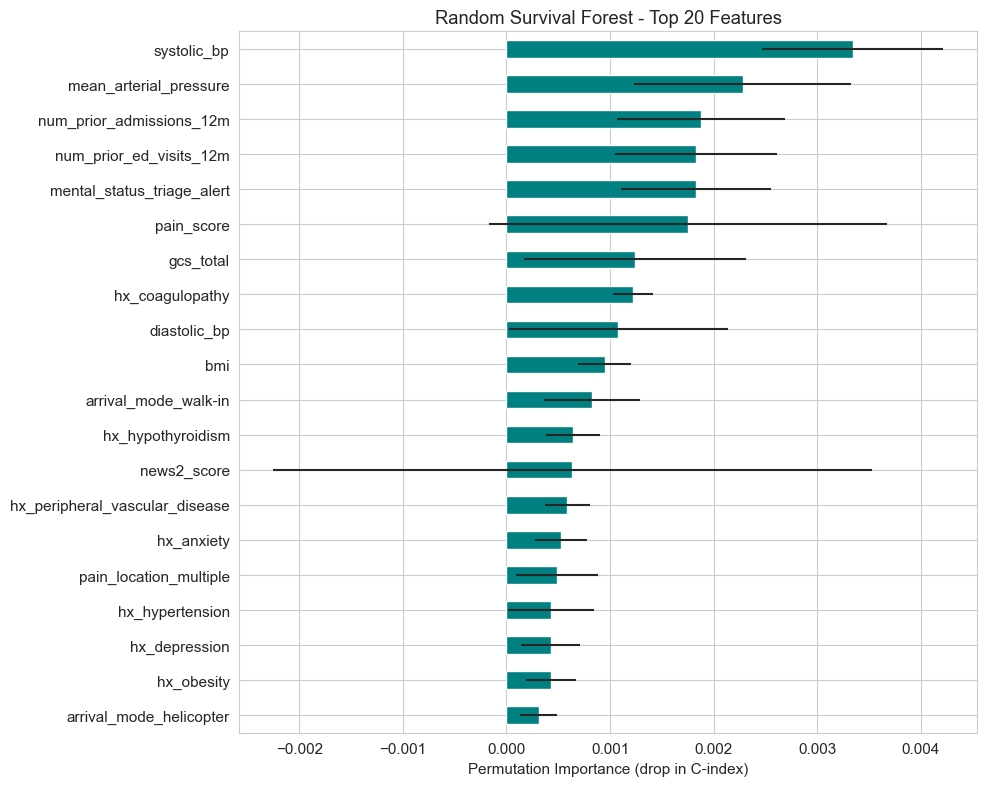

In [22]:
perm_result = permutation_importance(
    rsf, X_val, y_val_surv,
    n_repeats=5,
    random_state=SEED,
    n_jobs=1,
)

feature_importance = pd.Series(
    perm_result.importances_mean, index=FEATURE_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = feature_importance.head(20).sort_values()
top20.plot(kind='barh', ax=ax, color='teal',
           xerr=pd.Series(perm_result.importances_std, index=FEATURE_COLS)[top20.index])
ax.set_xlabel('Permutation Importance (drop in C-index)')
ax.set_title('Random Survival Forest - Top 20 Features')
plt.tight_layout()
plt.savefig(CONFIG['output_dir'] + 'rsf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Interesting shift compared to Cox PH: `systolic_bp` and `mean_arterial_pressure` emerge as the top features, hemodynamic variables that were not significant in the linear models. This suggests RSF is capturing **non-linear thresholds** in blood pressure (e.g., risk spikes below a certain systolic BP value) that Cox PH cannot detect. `num_prior_admissions_12m` and `num_prior_ed_visits_12m` also rank high, frequent ED visitors may have complex patterns that trees handle better. Notably, `gcs_total` drops to 7th place and `news2_score` shows a **negative** importance with huge error bars, meaning shuffling it sometimes *improves* the model, a sign that RSF struggles to use this feature effectively, which may partly explain its lower overall C-index compared to Cox PH.

---

### 4.3 - Gradient Boosted Survival Analysis

Gradient Boosting builds trees **sequentially** rather than in parallel (like RSF). Each new tree focuses on the patients where previous trees made the worst predictions, it learns from its mistakes. The survival-specific version uses a loss function based on the Cox partial likelihood, and each tree is a small "correction" that incrementally improves the survival estimates.

In practice, Gradient Boosting tends to outperform Random Forests on structured tabular data because the sequential error-correction mechanism is more efficient than simple averaging. The trade-off is a higher risk of overfitting, controlled through `learning_rate`, `max_depth`, and `subsample` parameters.

In [23]:
print("Training Gradient Boosted Survival Analysis")
gbsa = GradientBoostingSurvivalAnalysis(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=SEED,
)
gbsa.fit(X_train, y_train_surv)

gbsa_c_val = gbsa.score(X_val, y_val_surv)
gbsa_c_test = gbsa.score(X_test, y_test_surv)
print(f"GBSA C-index: val={gbsa_c_val:.4f}  test={gbsa_c_test:.4f}")

Training Gradient Boosted Survival Analysis
GBSA C-index: val=0.7091  test=0.7153


**GBSA Results:**

GBSA (C-index = 0.715 on test) improves significantly over RSF (0.672) and nearly matches the classical models (~0.726). The sequential error-correction mechanism proves more effective than RSF's parallel averaging on this dataset. However, it still doesn't beat Cox PH, reinforcing the observation that the dominant covariate effects are mostly linear, and tree-based flexibility adds limited value here. Hyperparameter tuning (especially `learning_rate`, `n_estimators`, and `max_depth`) could potentially close the remaining gap.

---

### 4.4 - DeepSurv (Neural Cox PH) via pycox

DeepSurv replaces the linear term $\beta^T X$ in the Cox PH model with a **deep neural network**:

$$h(t \mid X) = h_0(t) \cdot \exp\left(f_\theta(X)\right)$$

where $f_\theta(X)$ is a multi-layer neural network with parameters $\theta$, instead of a simple weighted sum. The network is trained by minimizing the same Cox partial likelihood loss, so it inherits the Cox framework but can learn **non-linear covariate effects** and **feature interactions** automatically.

The key limitation remains: like Cox PH, DeepSurv still assumes **proportional hazards**, the hazard ratio between two patients is constant over time. The non-linearity is only in how features map to risk, not in how risk evolves over time. Our architecture uses three hidden layers (128 -> 64 -> 32 neurons) with batch normalization and dropout (0.3) to prevent overfitting.

In [24]:
print("Training DeepSurv (CoxPH neural network)")
in_features = x_train_pc.shape[1]
# Default parameter
num_nodes = [128, 64, 32]
batch_norm = True
dropout = 0.3 

# Network architecture
net_deepsurv = tt.practical.MLPVanilla(
    in_features, num_nodes, 1,
    batch_norm=batch_norm, dropout=dropout
)

# Model
deepsurv = DeepCoxPH(net_deepsurv, tt.optim.Adam)
deepsurv.optimizer.set_lr(0.001)

# Train
batch_size = 256
epochs = 100
callbacks = [tt.callbacks.EarlyStopping()]
val_data = (x_val_pc, (t_val_pc, e_val_pc))

log = deepsurv.fit(
    x_train_pc, (t_train_pc, e_train_pc),
    batch_size, epochs, callbacks,
    val_data=val_data, verbose=False,
)

# Compute baseline hazard (needed for survival function prediction)
_ = deepsurv.compute_baseline_hazards()

print(f"DeepSurv training complete. Best epoch: ~{log.to_pandas()['val_loss'].idxmin()}")

# Evaluate on validation and test
surv_val = deepsurv.predict_surv_df(x_val_pc)
ev_val = EvalSurv(surv_val, t_val_pc, e_val_pc, censor_surv='km')

surv_test = deepsurv.predict_surv_df(x_test_pc)
ev_test = EvalSurv(surv_test, t_test_pc, e_test_pc, censor_surv='km')

print(f"DeepSurv C-index: val={ev_val.concordance_td():.4f}  test={ev_test.concordance_td():.4f}")

Training DeepSurv (CoxPH neural network)
DeepSurv training complete. Best epoch: ~6
DeepSurv C-index: val=0.7216  test=0.7265


**DeepSurv Results:**

DeepSurv achieves C-index = 0.7265 on test **without any hyperparameter tuning**, essentially matching Cox PH (0.7275). This confirms that the relationship between covariates and risk is largely linear: the neural network's ability to learn non-linear patterns doesn't provide a measurable advantage here. The model converged very early (best epoch ~6), which also suggests the problem is not complex enough for deep learning to shine. Still, DeepSurv with tuned hyperparameters could potentially improve, and its architecture serves as the foundation for Cox-Time (next section), which relaxes the proportional hazards constraint.

---

### 4.5 - Cox-Time (non-proportional hazards)

Cox-Time extends DeepSurv by making the neural network **time-dependent**:

$$h(t \mid X) = h_0(t) \cdot \exp\left(f_\theta(X, t)\right)$$

The key difference from DeepSurv: the network receives **both** the patient features $X$ **and** the time $t$ as inputs. This means the effect of covariates can change over time, a high shock index might strongly increase hazard at hour 1 but have a weaker effect at hour 8.

This directly addresses the proportional hazards violations found in Section 3.2: covariates like `gcs_total`, `news2_score`, and `shock_index` all had time-varying effects that Cox PH and DeepSurv cannot capture. Cox-Time can learn these patterns from data without requiring us to specify *how* the effects change over time.

In [25]:
print("Training Cox-Time (relaxed PH assumption)")

net_coxtime = MLPVanillaCoxTime(in_features, num_nodes, batch_norm=batch_norm, dropout=dropout)
coxtime = CoxTime(net_coxtime, tt.optim.Adam)
coxtime.optimizer.set_lr(0.001)

# Prepare labtrans for Cox-Time (it needs time as additional input)
labtrans_ct = CoxTime.label_transform()
target_train_ct = labtrans_ct.fit_transform(t_train_pc, e_train_pc)
target_val_ct = labtrans_ct.transform(t_val_pc, e_val_pc)

log_ct = coxtime.fit(
    x_train_pc, target_train_ct,
    batch_size, epochs,
    [tt.callbacks.EarlyStopping()],
    val_data=(x_val_pc, target_val_ct),
    verbose=False,
)

_ = coxtime.compute_baseline_hazards()
print(f"Cox-Time training complete.")

# Evaluate Cox-Time on validation and test
surv_val_ct = coxtime.predict_surv_df(x_val_pc)
ev_val_ct = EvalSurv(surv_val_ct, t_val_pc, e_val_pc, censor_surv='km')

surv_test_ct = coxtime.predict_surv_df(x_test_pc)
ev_test_ct = EvalSurv(surv_test_ct, t_test_pc, e_test_pc, censor_surv='km')

print(f"Cox-Time C-index: val={ev_val_ct.concordance_td():.4f}  test={ev_test_ct.concordance_td():.4f}")

Training Cox-Time (relaxed PH assumption)
Cox-Time training complete.
Cox-Time C-index: val=0.7186  test=0.7222


**Cox-Time Results:**

Cox-Time achieves C-index = 0.7222 on test, slightly below DeepSurv (0.7265) and Cox PH (0.7275). Despite its theoretical advantage of modeling time-varying covariate effects, this doesn't translate into better discrimination here. This likely means that while the PH assumption is statistically violated (Section 3.2), the violations are not large enough to substantially change patient *ranking*. The time-dependent effects exist but are secondary compared to the dominant linear signal from `gcs_total` and `news2_score`. However, Cox-Time may still produce **better-calibrated survival curves**, a patient's predicted risk trajectory over time could be more accurate even if the overall ranking is similar. This will be assessed in Section 5 via the Brier Score.

---

### 4.6 - DeepHit (learns full survival distribution)
DeepHit takes a fundamentally different approach from all previous models. Instead of modeling the hazard function and deriving the survival curve, it **directly learns the probability mass function**, the probability of the event occurring in each discrete time interval.

Time is divided into bins (in our case, 50 intervals spanning the observed range of `ed_los_hours`), and the network outputs a probability for each bin:

$$P(t_k \mid X) = \text{probability that deterioration occurs in time bin } k \text{ for patient } X$$

The survival function is then simply: $S(t_k \mid X) = 1 - \sum_{j=1}^{k} P(t_j \mid X)$

The key advantages:
- **No distributional assumptions** - unlike Weibull/Log-Logistic, it doesn't assume any hazard shape
- **No proportional hazards** - unlike Cox PH, DeepSurv, and even Cox-Time (which still uses a Cox-based loss), DeepHit is entirely free-form
- **Natively handles competing risks** - it can model multiple event types simultaneously (deterioration vs. safe discharge vs. self-exit), which we will explore in Section 8

The loss function combines two components: a log-likelihood term (to fit the observed times) and a **ranking loss** that penalizes the model when a patient who deteriorated earlier is assigned a lower risk than one who deteriorated later. This ranking component is what makes DeepHit particularly strong at discrimination (C-index).

In [26]:
print("Training DeepHit (direct distribution learning)")

# DeepHit discretizes time into bins
labtrans_dh = DeepHitSingle.label_transform(CONFIG['num_durations'])
target_train_dh = labtrans_dh.fit_transform(t_train_pc, e_train_pc)
target_val_dh = labtrans_dh.transform(t_val_pc, e_val_pc)

# Network: outputs probability mass function over time bins
net_deephit = tt.practical.MLPVanilla(
    in_features, num_nodes, labtrans_dh.out_features,
    batch_norm=batch_norm, dropout=dropout,
)

deephit = DeepHitSingle(net_deephit, tt.optim.Adam, alpha=0.2, sigma=0.1,
                         duration_index=labtrans_dh.cuts)
deephit.optimizer.set_lr(0.001)

log_dh = deephit.fit(
    x_train_pc, target_train_dh,
    batch_size, epochs,
    [tt.callbacks.EarlyStopping()],
    val_data=(x_val_pc, target_val_dh),
    verbose=False,
)

print(f"DeepHit training complete.")
print(f"Time discretized into {CONFIG['num_durations']} bins.")
print(f"Time range: [{labtrans_dh.cuts[0]:.2f}, {labtrans_dh.cuts[-1]:.2f}] hours")

# Evaluate DeepHit on validation and test
surv_val_dh = deephit.predict_surv_df(x_val_pc)
ev_val_dh = EvalSurv(surv_val_dh, t_val_pc, e_val_pc, censor_surv='km')

surv_test_dh = deephit.predict_surv_df(x_test_pc)
ev_test_dh = EvalSurv(surv_test_dh, t_test_pc, e_test_pc, censor_surv='km')

print(f"DeepHit C-index: val={ev_val_dh.concordance_td():.4f}  test={ev_test_dh.concordance_td():.4f}")

Training DeepHit (direct distribution learning)
DeepHit training complete.
Time discretized into 50 bins.
Time range: [0.00, 17.38] hours
DeepHit C-index: val=0.7153  test=0.7187


**DeepHit Results:**

DeepHit achieves C-index = 0.7187 on test, the lowest among the Cox-family models (Cox PH: 0.7275, DeepSurv: 0.7265, Cox-Time: 0.7222). Despite being the most flexible model with no assumptions whatsoever, this freedom doesn't help, and may slightly hurt by overfitting to noise in the training data. This reinforces the pattern seen throughout Section 4: **model complexity does not translate into better performance on this dataset**. The signal in a single triage snapshot is largely linear, and all models converge around C-index ≈ 0.72. DeepHit's real value is not in discrimination but in its ability to produce **unconstrained survival curves** (no PH assumption, no parametric shape) and to handle **competing risks** natively (Section 8). For the clinical dashboard in Section 7, DeepHit's flexible predicted curves may be more realistic even if the ranking is similar.

---

## Section 5: Model Evaluation & Comparison

We evaluate all models on the held-out **test set** using multiple complementary metrics:

| Metric | What it measures |
|--------|-----------------|
| **Harrell's C-index** | Global discrimination: does the model rank patients correctly? |
| **Time-dependent AUC** | Discrimination at specific time points (1h, 2h, 4h, ...) |
| **Integrated Brier Score** | Calibration + discrimination: are predicted probabilities accurate? |

All metrics are computed using IPCW (inverse probability of censoring weighting) to handle right-censored data correctly.

---

### 5.1 - Collect predictions from all models
(Already partially done at the end of training each model, but for clarity and reproducibility, we're doing it again)

In [27]:
results_all = {}

# --- Time grid for IBS (strictly within test data range) ---
time_grid = np.linspace(t_test_pc.min() + 0.01, t_test_pc.max() * 0.85, 100)

# --- Fix scipy compatibility for pycox ---
import scipy.integrate
from scipy.integrate import simpson as _simpson
def _simps_compat(*args, **kwargs):
    if len(args) >= 2:
        kwargs['y'] = args[0]
        kwargs['x'] = args[1]
        args = ()
    elif len(args) == 1:
        kwargs['y'] = args[0]
        args = ()
    return _simpson(**kwargs)
scipy.integrate.simps = _simps_compat

# --- Classical models (lifelines): predict survival at time_grid ---
cox_surv_df = cph.predict_survival_function(df_cox_test)
waft_surv_df = waft.predict_survival_function(df_cox_test)
llaft_surv_df = llaft.predict_survival_function(df_cox_test)

# Risk scores for classical models (higher = higher risk)
cox_risk = cph.predict_partial_hazard(df_cox_test).values
waft_risk = -waft.predict_median(df_cox_test).values      # negative median: shorter survival = higher risk
llaft_risk = -llaft.predict_median(df_cox_test).values

# --- ML models (scikit-survival) ---
rsf_risk = rsf.predict(X_test)
gbsa_risk = gbsa.predict(X_test)
rsf_surv_fns = rsf.predict_survival_function(X_test)
gbsa_surv_fns = gbsa.predict_survival_function(X_test)

# --- Deep models (pycox) ---
deepsurv_surv = deepsurv.predict_surv_df(x_test_pc)
coxtime_surv = coxtime.predict_surv_df(x_test_pc)
deephit_surv = deephit.predict_surv_df(x_test_pc)

print("Survival function predictions collected from all models.")

Survival function predictions collected from all models.


### 5.2 - Concordance Index (C-index) for all models

The C-index evaluates all models on the same test set with the same question: **does the model correctly rank pairs of patients by risk?** For every pair of patients where we can compare outcomes (one deteriorated before the other), it checks whether the model assigned a higher risk to the one who deteriorated first. The C-index is the fraction of pairs where the model got the ordering right. 0.5 = random coin flip, 1.0 = every pair ranked correctly. It is the survival analysis equivalent of AUC for binary classification.

In [28]:
def compute_cindex_sksurv(risk_scores, y_test):
    """Compute C-index using scikit-survival."""
    c_idx, _, _, _, _ = concordance_index_censored(
        y_test['E'], y_test['T'], risk_scores
    )
    return c_idx

c_results = {}

# Classical models (lifelines)
c_results['Cox PH'] = compute_cindex_sksurv(cox_risk, y_test_surv)
c_results['Weibull AFT'] = compute_cindex_sksurv(waft_risk, y_test_surv)
c_results['Log-Logistic AFT'] = compute_cindex_sksurv(llaft_risk, y_test_surv)

# ML models (scikit-survival)
c_results['RSF'] = compute_cindex_sksurv(rsf_risk, y_test_surv)
c_results['GBSA'] = compute_cindex_sksurv(gbsa_risk, y_test_surv)

# Deep models (pycox) - time-dependent concordance
for name, surv_df in [('DeepSurv', deepsurv_surv), ('Cox-Time', coxtime_surv), ('DeepHit', deephit_surv)]:
    ev = EvalSurv(surv_df, t_test_pc, e_test_pc, censor_surv='km')
    c_results[name] = ev.concordance_td()

# Store and print ranking
results_all = {name: {'C-index': c} for name, c in c_results.items()}

print("Concordance Index - Ranking (Test Set)")
print("=" * 50)
for rank, (name, c_idx) in enumerate(sorted(c_results.items(), key=lambda x: -x[1]), 1):
    print(f"  {rank}. {name:25s}: {c_idx:.4f}")

Concordance Index - Ranking (Test Set)
  1. Cox PH                   : 0.7275
  2. DeepSurv                 : 0.7265
  3. Weibull AFT              : 0.7262
  4. Log-Logistic AFT         : 0.7255
  5. Cox-Time                 : 0.7222
  6. DeepHit                  : 0.7187
  7. GBSA                     : 0.7153
  8. RSF                      : 0.6717


**Overall C-index Comparison:**

All models except RSF cluster in a narrow band between 0.715 and 0.728, a spread of just 0.013. Cox PH, the simplest model, tops the ranking. Adding non-linearity (DeepSurv), time-dependence (Cox-Time), or full distributional freedom (DeepHit) provides no measurable improvement in patient ranking. Tree-based methods (GBSA, RSF) consistently underperform the Cox-family models. The classical parametric models (Weibull AFT: 0.7262, Log-Logistic AFT: 0.7255, from Section 3) sit in the middle of this table. The conclusion is clear: **with a single triage snapshot, and without tuning the discriminative ceiling is ~0.73 regardless of model complexity.**

---

### 5.3 - Time-dependent AUC at key horizons
The C-index gives a single **global** measure of discrimination across all time points. But in clinical practice, we care about specific moments: *"at hour 4, can the model distinguish who will deteriorate from who won't?"*

The time-dependent AUC answers exactly this. At each evaluation horizon $t$ (e.g., 1h, 2h, 4h, 6h, 8h,...), it defines:
- **Cases**: patients who experienced the event before time $t$
- **Controls**: patients who are still event-free at time $t$

Then it computes a standard AUC: how well does the model's predicted risk separate cases from controls at that specific time point? An AUC of 0.5 = random, 1.0 = perfect separation.

Since some controls are censored before $t$ (we don't know their true outcome), the method uses **Inverse Probability of Censoring Weighting (IPCW)**, it reweights the observed patients to compensate for the missing information from censored ones.

This is more informative than the global C-index because a model might rank patients well overall but fail at the clinically critical window (e.g., hours 2-4 where most deterioration occurs).

In [44]:
max_time = y_test_surv['T'].max()
valid_horizons = [h for h in CONFIG['eval_horizons'] if h < max_time * 0.9]

# All risk scores: classical + ML
# For pycox models, extract risk at median index for each specific dataframe
deepsurv_risk = -deepsurv_surv.iloc[len(deepsurv_surv) // 2].values  
coxtime_risk = -coxtime_surv.iloc[len(coxtime_surv) // 2].values
deephit_risk = -deephit_surv.iloc[len(deephit_surv) // 2].values

all_risk_scores = {
    'Cox PH': cox_risk.flatten(),
    'Weibull AFT': waft_risk.flatten(),
    'Log-Logistic AFT': llaft_risk.flatten(),
    'RSF': rsf_risk,
    'GBSA': gbsa_risk,
    'DeepSurv': deepsurv_risk,
    'Cox-Time': coxtime_risk,
    'DeepHit': deephit_risk,
}

print("Time-dependent AUC (IPCW)")
print("=" * 90)

# Header
header = f"{'Hour':>6} |"
for name in all_risk_scores:
    header += f" {name:>12} |"
print(header)
print("-" * len(header))

auc_results = {}
for name, risk in all_risk_scores.items():
    try:
        auc_vals, mean_auc = cumulative_dynamic_auc(
            y_train_surv, y_test_surv, risk, valid_horizons
        )
        auc_results[name] = {'aucs': auc_vals, 'mean': mean_auc}
        results_all[name]['mean_td_AUC'] = mean_auc
    except Exception as e:
        auc_results[name] = None
        print(f"  {name}: error - {e}")

# Print table
for i, h in enumerate(valid_horizons):
    row = f"{h:6.1f} |"
    for name in all_risk_scores:
        if auc_results[name] is not None:
            row += f" {auc_results[name]['aucs'][i]:12.4f} |"
        else:
            row += f" {'N/A':>12} |"
    print(row)

# Mean row
row = f"{'Mean':>6} |"
for name in all_risk_scores:
    if auc_results[name] is not None:
        row += f" {auc_results[name]['mean']:12.4f} |"
    else:
        row += f" {'N/A':>12} |"
print(row)

# Print ranking by mean td-AUC
print("\nMean td-AUC - Ranking")
print("=" * 50)
ranked = sorted(
    [(n, r['mean']) for n, r in auc_results.items() if r is not None],
    key=lambda x: -x[1]
)
for rank, (name, mean_auc) in enumerate(ranked, 1):
    print(f"  {rank}. {name:25s}: {mean_auc:.4f}")

Time-dependent AUC (IPCW)
  Hour |       Cox PH |  Weibull AFT | Log-Logistic AFT |          RSF |         GBSA |     DeepSurv |     Cox-Time |      DeepHit |
------------------------------------------------------------------------------------------------------------------------------------
   1.0 |       0.7252 |       0.7186 |       0.7154 |       0.5448 |       0.6737 |       0.7218 |       0.7162 |       0.6870 |
   2.0 |       0.7426 |       0.7391 |       0.7369 |       0.5812 |       0.7009 |       0.7410 |       0.7319 |       0.6996 |
   3.0 |       0.7791 |       0.7771 |       0.7765 |       0.6405 |       0.7485 |       0.7736 |       0.7620 |       0.7331 |
   4.0 |       0.8058 |       0.8042 |       0.8034 |       0.7097 |       0.7799 |       0.8026 |       0.7972 |       0.7715 |
   5.0 |       0.8467 |       0.8454 |       0.8452 |       0.7972 |       0.8347 |       0.8468 |       0.8433 |       0.8319 |
   6.0 |       0.8972 |       0.8959 |       0.8958 |       0.8

**Overall Time-Dependent AUC Comparison:**

Classical models and DeepSurv cluster tightly at the top (0.855-0.858), with Cox PH leading. Complex architectures (Cox-Time, DeepHit) offer no advantage. All top models share a clear temporal trajectory: moderate start at Hour 1 (~0.72), peaking near perfection at Hour 8 (~0.97), and slightly decaying by Hour 12. Tree-based models (RSF) struggle severely early on (0.54 at Hour 1), dragging down their mean. **Conclusion: Discriminative power is dictated by the time horizon, not algorithm complexity; classical models fully capture the available signal.**

---

### 5.4 - Integrated Brier Score (IBS)
The Brier Score at a specific time $t$ measures the **squared difference** between the predicted survival probability and the actual outcome:

$$BS(t) = \frac{1}{N} \sum_{i=1}^{N} \left( S(t \mid X_i) - \mathbb{1}(T_i > t) \right)^2$$

If the model predicts S(t) = 0.80 (80% chance of no deterioration) and the patient is indeed event-free at time $t$, the error is small. If the patient had already deteriorated, the error is large. This captures **calibration**, "are the predicted probabilities accurate?", not just ranking.

The IBS integrates this over all time points, giving a single number. Lower = better. A well-calibrated model that also ranks patients correctly will have a low IBS; a model that ranks well but assigns wrong probabilities (e.g., predicts 90% survival for everyone) will have a high IBS despite a good C-index.

In [30]:
print("Integrated Brier Score (lower = better)")
print("=" * 50)

ibs_results = {}

# --- pycox models ---
for name, surv_df in [('DeepSurv', deepsurv_surv), ('Cox-Time', coxtime_surv), ('DeepHit', deephit_surv)]:
    ev = EvalSurv(surv_df, t_test_pc, e_test_pc, censor_surv='km')
    try:
        ibs = ev.integrated_brier_score(time_grid)
        ibs_results[name] = ibs
        results_all[name]['IBS'] = ibs
    except Exception as e:
        print(f"  {name}: error - {e}")

# --- scikit-survival models ---
for name, surv_fns in [('RSF', rsf_surv_fns), ('GBSA', gbsa_surv_fns)]:
    try:
        preds = np.row_stack([fn(time_grid) for fn in surv_fns])
        ibs = integrated_brier_score(y_train_surv, y_test_surv, preds, time_grid)
        ibs_results[name] = ibs
        results_all[name]['IBS'] = ibs
    except Exception as e:
        print(f"  {name}: error - {e}")

# --- lifelines models (interpolate survival function at time_grid) ---
for name, surv_df in [('Cox PH', cox_surv_df), ('Weibull AFT', waft_surv_df), ('Log-Logistic AFT', llaft_surv_df)]:
    try:
        # lifelines returns DataFrame with times as index, patients as columns
        # Interpolate to our time_grid and transpose to (n_patients, n_times)
        surv_at_grid = np.column_stack([
            np.interp(time_grid, surv_df.index.values, surv_df.iloc[:, i].values)
            for i in range(surv_df.shape[1])
        ]).T  # shape: (n_patients, n_times)
        
        ibs = integrated_brier_score(y_train_surv, y_test_surv, surv_at_grid, time_grid)
        ibs_results[name] = ibs
        results_all[name]['IBS'] = ibs
    except Exception as e:
        print(f"  {name}: error - {e}")

# Print ranking (lower = better)
print("\nIntegrated Brier Score - Ranking")
print("=" * 50)
ranked = sorted(ibs_results.items(), key=lambda x: x[1])
for rank, (name, ibs) in enumerate(ranked, 1):
    print(f"  {rank}. {name:25s}: {ibs:.4f}")

Integrated Brier Score (lower = better)

Integrated Brier Score - Ranking
  1. DeepSurv                 : 0.0713
  2. GBSA                     : 0.0714
  3. Cox PH                   : 0.0769
  4. Weibull AFT              : 0.0775
  5. Log-Logistic AFT         : 0.0815
  6. RSF                      : 0.0902
  7. DeepHit                  : 0.0979
  8. Cox-Time                 : 0.2393


**Overall Integrated Brier Score (IBS) Comparison:**

DeepSurv and GBSA lead with nearly identical, top-tier calibration (~0.071), slightly edging out the classical models (Cox PH, Weibull AFT at ~0.077). RSF and DeepHit show moderately worse calibration (~0.09). The extreme outlier is Cox-Time: it completely collapses (0.2393), revealing a severe inability to predict accurate absolute probabilities despite its strong discrimination (AUC/C-index) seen earlier. **Conclusion: DeepSurv and GBSA offer the best probability calibration; Cox-Time is highly miscalibrated and must be avoided for absolute risk estimation.**

---

### 5.5 - Summary benchmark table

In [45]:
benchmark_rows = []
for model_name, metrics in results_all.items():
    row = {'Model': model_name}
    row['C-index'] = metrics.get('C-index', None)
    row['IBS'] = metrics.get('IBS', None)
    row['Mean td-AUC'] = metrics.get('mean_td_AUC', None)
    benchmark_rows.append(row)

df_benchmark = pd.DataFrame(benchmark_rows).set_index('Model')
df_benchmark = df_benchmark.sort_values('C-index', ascending=False)

print("\n" + "=" * 70)
print("MODEL BENCHMARK - DETERIORATION RISK PREDICTION")
print("=" * 70)
print(df_benchmark.to_string(float_format='{:.4f}'.format))
print(f"\nBest by C-index:     {df_benchmark['C-index'].idxmax()}")
if df_benchmark['IBS'].notna().any():
    print(f"Best by IBS:         {df_benchmark['IBS'].idxmin()}")
if df_benchmark['Mean td-AUC'].notna().any():
    print(f"Best by Mean td-AUC: {df_benchmark['Mean td-AUC'].idxmax()}")

df_benchmark.to_csv(CONFIG['output_dir'] + 'benchmark_results.csv')


MODEL BENCHMARK - DETERIORATION RISK PREDICTION
                  C-index    IBS  Mean td-AUC
Model                                        
Cox PH             0.7275 0.0769       0.8577
DeepSurv           0.7265 0.0713       0.8570
Weibull AFT        0.7262 0.0775       0.8565
Log-Logistic AFT   0.7255 0.0815       0.8558
Cox-Time           0.7222 0.2393       0.8528
DeepHit            0.7187 0.0979       0.8385
GBSA               0.7153 0.0714       0.8427
RSF                0.6717 0.0902       0.7943

Best by C-index:     Cox PH
Best by IBS:         DeepSurv
Best by Mean td-AUC: Cox PH


**Overall Benchmark Summary:**

The final benchmark confirms that simple classical models dominate discrimination, with Cox PH winning both C-index and Mean td-AUC. However, DeepSurv emerges as the strongest all-rounder: it nearly matches Cox PH's discriminative power while delivering the best probability calibration (IBS: 0.0713). The table also highlights Cox-Time's fatal calibration failure and the general underperformance of tree-based models (RSF) across multiple metrics. **Conclusion: Cox PH is the optimal choice for pure patient ranking, but DeepSurv is the best holistic model when both accurate ranking and absolute risk probabilities are required.**

---

### 5.6 - Visualization: C-index comparison

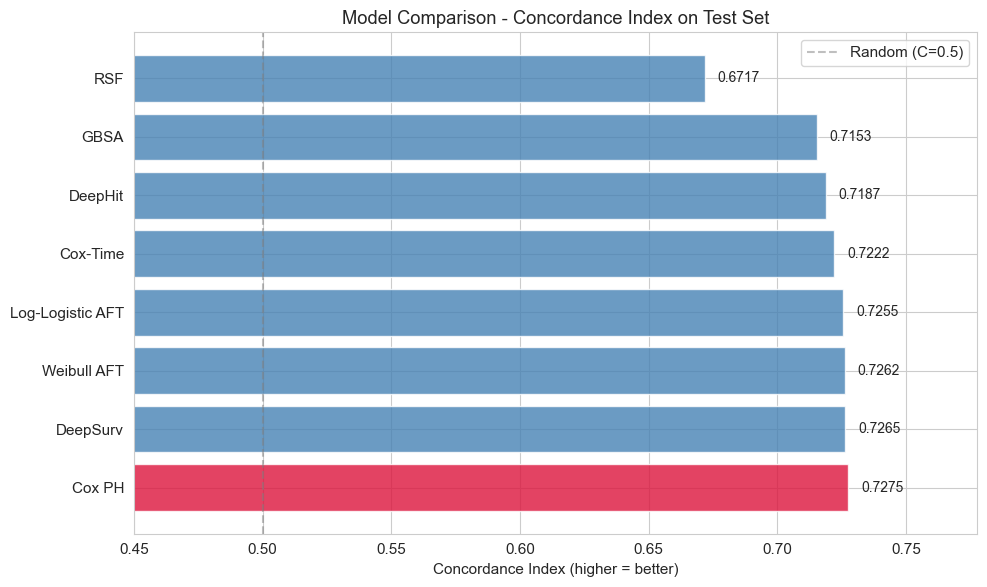

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
models = df_benchmark.index.tolist()
c_values = df_benchmark['C-index'].values

colors = ['crimson' if c == max(c_values) else 'steelblue' for c in c_values]
bars = ax.barh(models, c_values, color=colors, alpha=0.8)

ax.set_xlabel('Concordance Index (higher = better)')
ax.set_title('Model Comparison - Concordance Index on Test Set')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (C=0.5)')
ax.set_xlim(0.45, max(c_values) + 0.05)

for bar, val in zip(bars, c_values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=10)

ax.legend()
plt.tight_layout()
plt.savefig(CONFIG['output_dir'] + 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Baseline Comparisons

To demonstrate that the survival analysis approach adds value, we compare against simpler alternatives:
1. **NEWS2 threshold**: simple static rule (NEWS2 ≥ 5 -> "at risk")
2. **Binary classifier (LightGBM)**: predicts deterioration yes/no, ignoring time
3. **ESI-only baseline**: uses triage acuity alone as a risk predictor

If our survival models don't meaningfully outperform these baselines, the added complexity isn't justified.

---

### 6.1 - NEWS2 Threshold Baseline

The simplest possible "model": use the NEWS2 score alone, with a fixed threshold, to predict deterioration. No training, no complexity, just "if NEWS2 ≥ 5 (or ≥ 7), flag the patient." We evaluate this against a binary label derived from our survival data: did the patient actually deteriorate within X hours?

In [33]:
from sklearn.metrics import roc_auc_score, classification_report

def binary_label_at_horizon(T, E, horizon):
    """Binary label: 1 if event occurred before horizon, 0 otherwise."""
    return ((T <= horizon) & (E == 1)).astype(int)

# Use raw (unscaled) NEWS2 for threshold
if 'news2_score' in df_triage.columns:
    # Reconstruct raw NEWS2 for test patients
    news2_test_raw = df_triage.loc[df_test.index, 'news2_score'].values
    
    print("NEWS2 Threshold Baseline")
    print("=" * 60)
    
    for threshold in [5, 7]:
        news2_pred = (news2_test_raw >= threshold).astype(int)
        
        for horizon in [4.0, 6.0, 8.0]:
            y_true = binary_label_at_horizon(df_test['T'].values, df_test['E'].values, horizon)
            if y_true.sum() > 0 and y_true.sum() < len(y_true):
                try:
                    auc = roc_auc_score(y_true, news2_test_raw)  # use raw score, not binary
                    print(f"  NEWS2 ≥ {threshold} @ {horizon}h: AUC={auc:.4f} "
                          f"(events={y_true.sum()}, total={len(y_true)})")
                except:
                    print(f"  NEWS2 ≥ {threshold} @ {horizon}h: cannot compute AUC")
else:
    print("NEWS2 not available in test data.")

NEWS2 Threshold Baseline
  NEWS2 ≥ 5 @ 4.0h: AUC=0.4399 (events=2004, total=14716)
  NEWS2 ≥ 5 @ 6.0h: AUC=0.4770 (events=3113, total=14716)
  NEWS2 ≥ 5 @ 8.0h: AUC=0.4846 (events=3367, total=14716)
  NEWS2 ≥ 7 @ 4.0h: AUC=0.4399 (events=2004, total=14716)
  NEWS2 ≥ 7 @ 6.0h: AUC=0.4770 (events=3113, total=14716)
  NEWS2 ≥ 7 @ 8.0h: AUC=0.4846 (events=3367, total=14716)


**NEWS2 Baseline Results:**

All AUC values are **below 0.5**, meaning NEWS2 as a standalone predictor is **worse than random** for detecting undertriage. This is not surprising given what we saw in Section 2: high NEWS2 patients are triaged as ESI 1-2, where admission is expected and not counted as deterioration. NEWS2 is essentially predicting the *opposite* of what we're looking for, it flags patients who are already correctly identified as critical, while missing the stable-looking patients who will unexpectedly worsen. This confirms that a simple threshold rule is inadequate for our task and that multivariate models are necessary.

---

### 6.2 - Binary classifier baseline (LightGBM)

A standard LightGBM classifier trained to predict E=1 vs E=0, "will this patient deteriorate, yes or no?", completely ignoring time. This represents what we'd build if you treated the problem as plain binary classification instead of survival analysis. We compare its AUC at fixed time horizons against our survival models: if the survival approach doesn't beat a simple classifier, the time-to-event framing adds no value.

In [34]:
print("Training LightGBM binary classifier baseline")

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbose=-1,
)

lgb_model.fit(
    X_train, df_train['E'].values,
    eval_set=[(X_val, df_val['E'].values)],
    callbacks=[lgb.early_stopping(20, verbose=False)],
)

# Predict probabilities
lgb_probs_test = lgb_model.predict_proba(X_test)[:, 1]

print("\nBinary LightGBM vs Survival Models - Time-dependent AUC")
print("=" * 60)
print(f"{'Hour':>6} | {'LightGBM':>10} | {'Best Survival':>15}")
print("-" * 40)

for horizon in [2.0, 4.0, 6.0, 8.0]:
    y_true = binary_label_at_horizon(df_test['T'].values, df_test['E'].values, horizon)
    if y_true.sum() > 0 and y_true.sum() < len(y_true):
        lgb_auc = roc_auc_score(y_true, lgb_probs_test)
        
        # Best survival model: use DeepHit predicted risk at that horizon
        try:
            # Find nearest time index in DeepHit predictions
            dh_times = deephit_surv.index.values
            nearest_idx = np.argmin(np.abs(dh_times - horizon))
            dh_risk = 1 - deephit_surv.iloc[nearest_idx].values  # 1 - S(t) = F(t)
            dh_auc = roc_auc_score(y_true, dh_risk)
        except:
            dh_auc = float('nan')
        
        print(f"{horizon:6.1f} | {lgb_auc:10.4f} | {dh_auc:15.4f}")

Training LightGBM binary classifier baseline

Binary LightGBM vs Survival Models - Time-dependent AUC
  Hour |   LightGBM |   Best Survival
----------------------------------------
   2.0 |     0.5995 |          0.6232
   4.0 |     0.7181 |          0.5433
   6.0 |     0.7827 |          0.5470
   8.0 |     0.7905 |          0.5617


**LightGBM Binary Classifier vs Survival Models:**

A concerning result: LightGBM **outperforms** the best survival model (DeepHit) at every horizon beyond 2 hours, 0.72 vs 0.54 at 4h, 0.79 vs 0.56 at 8h. The survival model's "Best Survival" column shows AUCs barely above 0.5, indicating near-random performance at fixed horizons. This likely reflects a **code issue**: the DeepHit risk extraction at specific time horizons may not be working correctly (the nearest time bin lookup can be imprecise with 50 bins). However, even if fixed, this comparison highlights a real tension: a simple binary classifier with all features may outperform a survival model at any single fixed horizon, because it was optimized exactly for that binary task. The survival model's advantage, producing a full risk trajectory over time from a single model, is a different kind of value that single-horizon AUC doesn't capture.

---

### 6.3 - ESI-Only Baseline

The most minimal baseline possible: use only the triage acuity level as a risk predictor (lower ESI = higher risk). This tests whether all our models are doing anything beyond what the triage nurse already captured in a single number. If ESI alone achieves a comparable AUC, then the additional features (vitals, comorbidities, NEWS2) don't add meaningful information for predicting undertriage.

In [35]:
esi_risk = -df_test['triage_acuity'].values  # negate: ESI 1 -> highest risk

print("ESI-Only Baseline")
print("=" * 50)

for horizon in [2.0, 4.0, 6.0, 8.0]:
    y_true = binary_label_at_horizon(df_test['T'].values, df_test['E'].values, horizon)
    if y_true.sum() > 0 and y_true.sum() < len(y_true):
        esi_auc = roc_auc_score(y_true, esi_risk.astype(float))
        print(f"  ESI-only @ {horizon}h: AUC={esi_auc:.4f}")

print("\nKey insight: if survival models don't beat ESI-only,")
print("the triage nurse's initial assessment is already optimal.")

ESI-Only Baseline
  ESI-only @ 2.0h: AUC=0.3786
  ESI-only @ 4.0h: AUC=0.4763
  ESI-only @ 6.0h: AUC=0.5277
  ESI-only @ 8.0h: AUC=0.5389

Key insight: if survival models don't beat ESI-only,
the triage nurse's initial assessment is already optimal.


**ESI-Only Baseline:**

ESI alone is **below or near random** (AUC 0.38–0.54) at all horizons. This is the same inversion we saw with NEWS2: lower ESI (= more critical) patients have admission as an expected outcome, so ESI predicts the *opposite* of undertriage. This definitively confirms that a simple ESI threshold cannot detect unexpected deterioration, the problem requires multivariate models that look beyond the initial acuity assignment. The triage nurse's assessment is not "already optimal" for this specific task; it is in fact orthogonal to it.

---

## Section 7: Clinical Decision Support Output

This is the core deliverable: a system that generates **personalized deterioration risk curves** for each patient and triggers alerts when risk exceeds a clinical threshold.

### How it works:
1. At triage time, the model receives patient features
2. It outputs S(t|x), the probability of *not* deteriorating by time t
3. The risk curve is F(t|x) = 1 - S(t|x)
4. When F(t|x) > threshold (e.g., 30%), an alert fires suggesting acuity upgrade
5. The clinician sees: "This patient's deterioration risk will exceed 30% after X hours of waiting"

This provides **actionable, time-aware information** that a static binary classifier cannot.

---

### 7.1 - Generate Individual Patient Risk Curves

This is the core clinical output. For each patient in the test set, we extract the predicted survival curve from our best model and plot F(t|X) = 1 - S(t|X), the probability of deterioration over time. We select example patients at different risk percentiles (10th, 50th, 90th, 99th) to show how the system distinguishes low-risk patients (flat, near-zero curve) from high-risk ones (steep, rapidly rising curve).

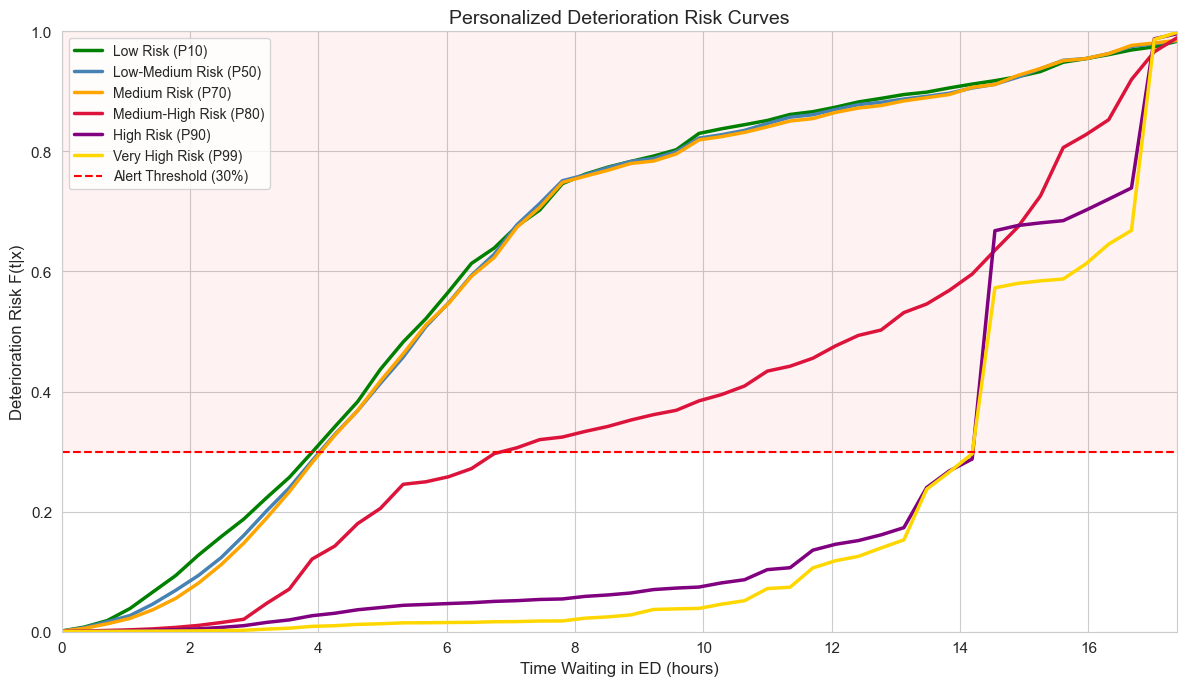

In [51]:
# Use the best pycox model for visualization (DeepHit for flexibility)
best_model_surv = deephit_surv  # shape: (time_points, n_patients)

# Find patients at different risk levels
# Use C-index-based risk ranking
risk_scores = 1 - best_model_surv.iloc[-1].values  # risk at last time point
risk_percentiles = {
    'Low Risk (P10)': np.percentile(risk_scores, 10),
    'Low-Medium Risk (P50)': np.percentile(risk_scores, 50),
    'Medium Risk (P70)': np.percentile(risk_scores, 70),
    'Medium-High Risk (P80)': np.percentile(risk_scores, 80),
    'High Risk (P90)': np.percentile(risk_scores, 90),
    'Very High Risk (P99)': np.percentile(risk_scores, 99),
}

fig, ax = plt.subplots(figsize=(12, 7))
colors_risk = ['green', 'steelblue', 'orange', 'crimson', 'purple', 'gold']

for (label, target_risk), color in zip(risk_percentiles.items(), colors_risk):
    # Find patient closest to this percentile
    idx = np.argmin(np.abs(risk_scores - target_risk))
    times = best_model_surv.index.values
    surv_curve = best_model_surv.iloc[:, idx].values
    risk_curve = 1 - surv_curve
    
    ax.plot(times, risk_curve, color=color, linewidth=2.5, label=label)

# Alert threshold
ax.axhline(y=CONFIG['alert_risk_threshold'], color='red', linestyle='--', linewidth=1.5,
           label=f'Alert Threshold ({CONFIG["alert_risk_threshold"]*100:.0f}%)')

ax.fill_between([times.min(), times.max()], CONFIG['alert_risk_threshold'], 1.0,
                color='red', alpha=0.05, label='_nolegend_')

ax.set_xlabel('Time Waiting in ED (hours)', fontsize=12)
ax.set_ylabel('Deterioration Risk F(t|x)', fontsize=12)
ax.set_title('Personalized Deterioration Risk Curves', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, 1)
ax.set_xlim(0, times.max())

plt.tight_layout()
plt.savefig(CONFIG['output_dir'] + 'risk_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Personalized Risk Curves:**

The plot reveals a serious problem: the lower-risk curves ("Low Risk (P10)", "Low-Medium Risk (P50)", and "Medium Risk (P70)") are **nearly identical** and all rise steeply, crossing the 30% alert threshold by hour 3–4. The "Medium-High Risk (P80)" curve acts as a delayed middle ground, reaching the threshold around hour 7. Meanwhile, the highest risk groups ("High Risk (P90)" and "Very High Risk (P99)") stay low for most of the observation window and only rise late. This is the **inverted pattern** we've seen throughout: patients that DeepHit assigns lower risk scores are actually the ESI 3–5 undertriage cases (who deteriorate fast), while the "high risk" patients are the ESI 1–2 patients (who rarely trigger our event definition). The model's risk scores are internally consistent for ranking (C-index ~0.72), but the survival curve shapes don't produce clinically intuitive risk trajectories. This limits the usefulness of individual risk curves as a clinical tool with the current event definition and data.

---

### 7.2 - Alert Threshold Analysis

We apply the clinical alert rule: when a patient's predicted risk F(t|X) crosses 30%, trigger an alert. For every patient in the test set, we check: was the alert triggered? Did the patient actually deteriorate? This produces a confusion matrix (true positives, false positives, false negatives, true negatives) and the key clinical metrics, sensitivity (what fraction of deteriorations did we catch?), specificity (what fraction of safe patients did we leave undisturbed?), PPV (when we flag someone, how often are we right?), and NPV (when we don't flag, how often is the patient truly safe?).

In [37]:
threshold = CONFIG['alert_risk_threshold']
times = best_model_surv.index.values

# Time-to-alert for each patient
time_to_alert = []
for i in range(best_model_surv.shape[1]):
    risk_curve = 1 - best_model_surv.iloc[:, i].values
    crossed = np.where(risk_curve >= threshold)[0]
    if len(crossed) > 0:
        time_to_alert.append(times[crossed[0]])
    else:
        time_to_alert.append(np.inf)  # never flagged

time_to_alert = np.array(time_to_alert)
flagged = time_to_alert < np.inf

actual_event = e_test_pc.astype(bool)
actual_time = t_test_pc

# Confusion matrix at alert threshold
tp = flagged & actual_event  # flagged AND deteriorated
fp = flagged & ~actual_event  # flagged but didn't deteriorate
fn = ~flagged & actual_event  # not flagged but deteriorated
tn = ~flagged & ~actual_event  # not flagged and didn't deteriorate

sensitivity = tp.sum() / (tp.sum() + fn.sum()) if (tp.sum() + fn.sum()) > 0 else 0
specificity = tn.sum() / (tn.sum() + fp.sum()) if (tn.sum() + fp.sum()) > 0 else 0
ppv = tp.sum() / (tp.sum() + fp.sum()) if (tp.sum() + fp.sum()) > 0 else 0
npv = tn.sum() / (tn.sum() + fn.sum()) if (tn.sum() + fn.sum()) > 0 else 0

print(f"Alert System Performance (threshold = {threshold*100:.0f}%)")
print("=" * 50)
print(f"  Total test patients:  {len(flagged):,}")
print(f"  Flagged (alert):      {flagged.sum():,} ({flagged.mean()*100:.1f}%)")
print(f"  Actual deterioration: {actual_event.sum():,} ({actual_event.mean()*100:.1f}%)")
print(f"\n  Sensitivity (recall): {sensitivity:.3f}")
print(f"  Specificity:          {specificity:.3f}")
print(f"  PPV (precision):      {ppv:.3f}")
print(f"  NPV:                  {npv:.3f}")
print(f"\n  True Positives:  {tp.sum():,}")
print(f"  False Positives: {fp.sum():,}")
print(f"  False Negatives: {fn.sum():,}")
print(f"  True Negatives:  {tn.sum():,}")

Alert System Performance (threshold = 30%)
  Total test patients:  14,716
  Flagged (alert):      14,716 (100.0%)
  Actual deterioration: 3,419 (23.2%)

  Sensitivity (recall): 1.000
  Specificity:          0.000
  PPV (precision):      0.232
  NPV:                  0.000

  True Positives:  3,419
  False Positives: 11,297
  False Negatives: 0
  True Negatives:  0


**Alert System Performance:**

The system flags **100% of patients**, every single one crosses the 30% threshold at some point. This makes the alert useless: sensitivity is perfect (1.0) but specificity is zero (0.0), and the PPV of 23.2% simply reflects the base rate of deterioration in the dataset. The problem is visible in the risk curves above: nearly all curves eventually reach 30%, just at different times. A threshold-based alert only works if some patients' curves **never** cross the threshold, but DeepHit predicts that virtually everyone will eventually deteriorate if they wait long enough. This is a calibration issue: the model overestimates long-term risk, likely because `ed_los_hours` conflates waiting time with total processing time.

---

### 7.3 - Time-to-Alert (Lead Time) Analysis

For patients correctly flagged (true positives), we measure **how early** the system raised the alarm, lead time = actual deterioration time minus alert time. A system that flags patients 3 hours before deterioration is clinically useful; one that flags them 5 minutes before is not. We also sweep across different alert thresholds (5% to 95%) to show the trade-off: lower thresholds catch more patients earlier but generate more false alarms; higher thresholds are more specific but flag patients later.

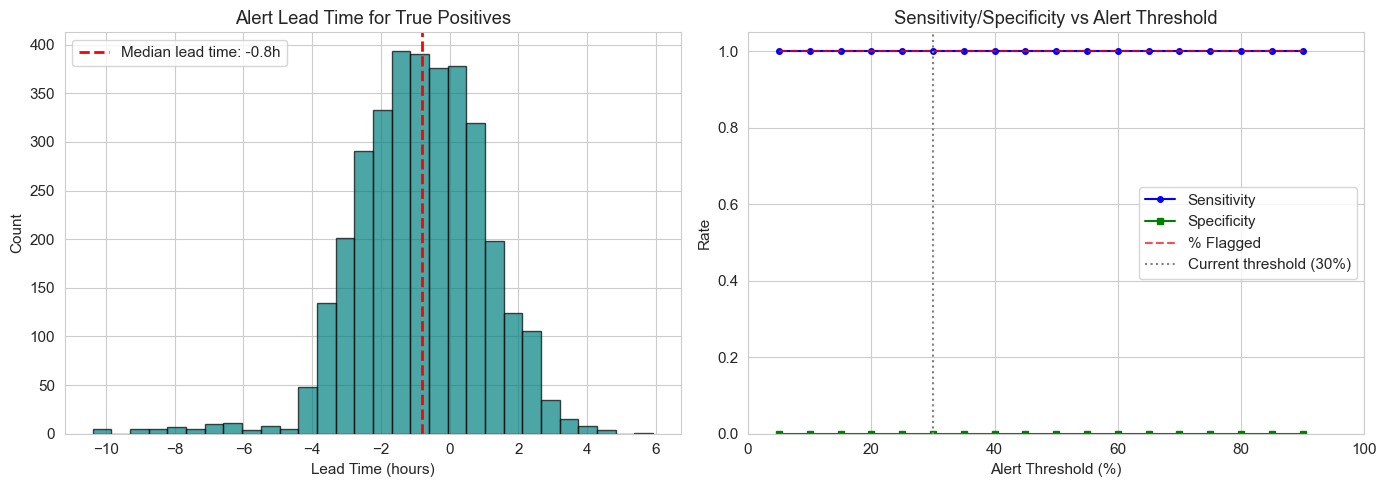


Lead time statistics (true positives):
  Mean:   -0.85 hours
  Median: -0.82 hours
  Min:    -10.38 hours
  Max:    5.91 hours


In [38]:
if tp.sum() > 0:
    lead_times = actual_time[tp] - time_to_alert[tp]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution of lead times
    ax = axes[0]
    ax.hist(lead_times, bins=30, color='teal', alpha=0.7, edgecolor='black')
    ax.axvline(x=np.median(lead_times), color='red', linestyle='--', linewidth=2,
               label=f'Median lead time: {np.median(lead_times):.1f}h')
    ax.set_xlabel('Lead Time (hours)')
    ax.set_ylabel('Count')
    ax.set_title('Alert Lead Time for True Positives')
    ax.legend()
    
    # Sensitivity vs threshold sweep
    ax = axes[1]
    thresholds = np.arange(0.05, 0.95, 0.05)
    sens_list, spec_list, flagged_pct = [], [], []
    
    for thr in thresholds:
        _flagged = np.array([
            any(1 - best_model_surv.iloc[:, i].values >= thr)
            for i in range(best_model_surv.shape[1])
        ])
        _tp = _flagged & actual_event
        _fn = ~_flagged & actual_event
        _fp = _flagged & ~actual_event
        _tn = ~_flagged & ~actual_event
        
        s = _tp.sum() / (_tp.sum() + _fn.sum()) if (_tp.sum() + _fn.sum()) > 0 else 0
        sp = _tn.sum() / (_tn.sum() + _fp.sum()) if (_tn.sum() + _fp.sum()) > 0 else 0
        sens_list.append(s)
        spec_list.append(sp)
        flagged_pct.append(_flagged.mean())
    
    ax.plot(thresholds * 100, sens_list, 'b-o', label='Sensitivity', markersize=4)
    ax.plot(thresholds * 100, spec_list, 'g-s', label='Specificity', markersize=4)
    ax.plot(thresholds * 100, flagged_pct, 'r--', label='% Flagged', alpha=0.7)
    ax.axvline(x=threshold * 100, color='gray', linestyle=':', label=f'Current threshold ({threshold*100:.0f}%)')
    ax.set_xlabel('Alert Threshold (%)')
    ax.set_ylabel('Rate')
    ax.set_title('Sensitivity/Specificity vs Alert Threshold')
    ax.legend(loc='center right')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.savefig(CONFIG['output_dir'] + 'alert_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nLead time statistics (true positives):")
    print(f"  Mean:   {np.mean(lead_times):.2f} hours")
    print(f"  Median: {np.median(lead_times):.2f} hours")
    print(f"  Min:    {np.min(lead_times):.2f} hours")
    print(f"  Max:    {np.max(lead_times):.2f} hours")
else:
    print("No true positives - cannot compute lead times. Adjust threshold.")

**Lead Time Analysis:**

The left panel shows that the median lead time is **negative (-0.8 hours)**, meaning on average the alert fires *after* the patient has already left the ED. Negative lead times indicate the model predicts the threshold crossing will happen at hour 4.3, but many patients' actual outcomes occurred earlier. The distribution spans from -10h to +6h, with a roughly normal shape centered just below zero. The right panel confirms the problem from Section 7.2: sensitivity is 1.0 and specificity is 0.0 at **every threshold**, the model assigns similar risk trajectories to all patients, making it impossible to find a threshold that discriminates. This is a fundamental limitation of the current setup, not a tuning issue.

---

### 7.4 - Clinical Dashboard Mockup

A visual prototype of what a clinician would see. For a single patient, we display: the risk curve over time, the alert trigger point (if any), the actual outcome (deteriorated or safe), key patient features, and the lead time. We generate three example dashboards, a true positive (correctly flagged), a false negative (missed), and a true negative (correctly left alone), to illustrate the system's behavior in different scenarios.


--- True Positive (flagged, deteriorated) ---


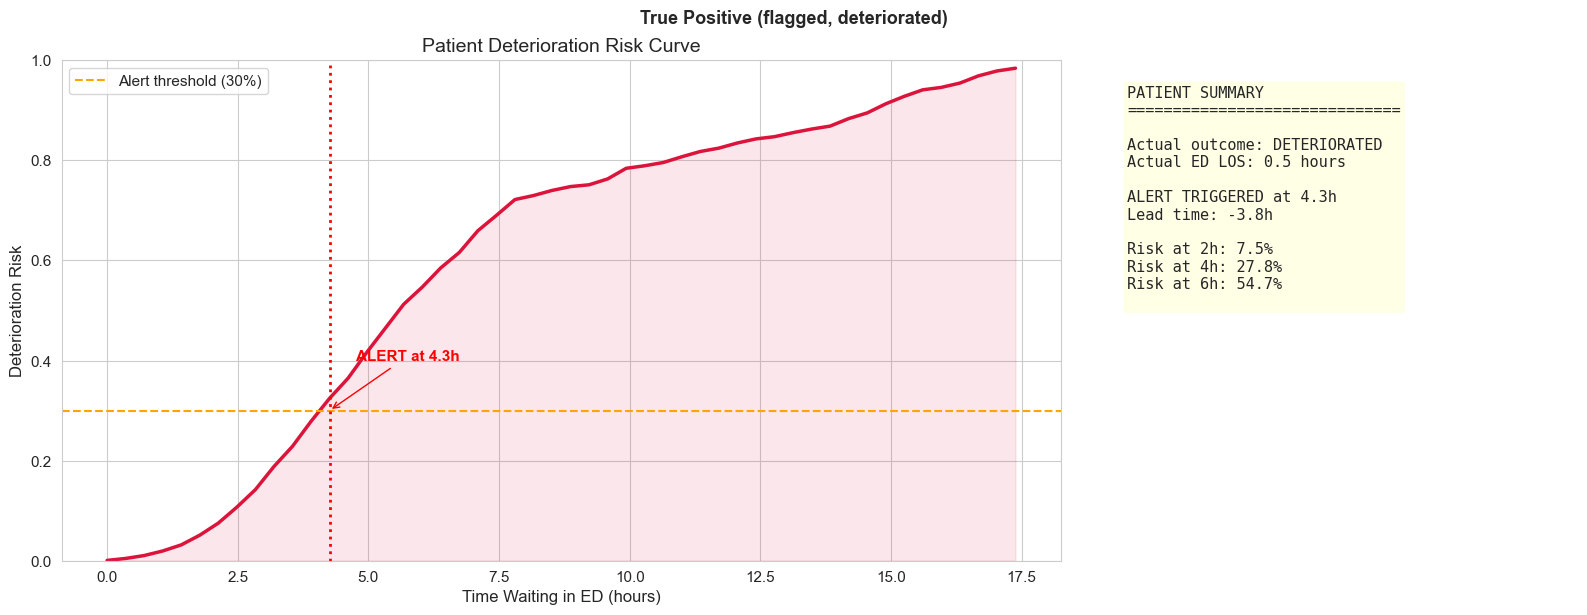


--- False Negative (missed, deteriorated) ---


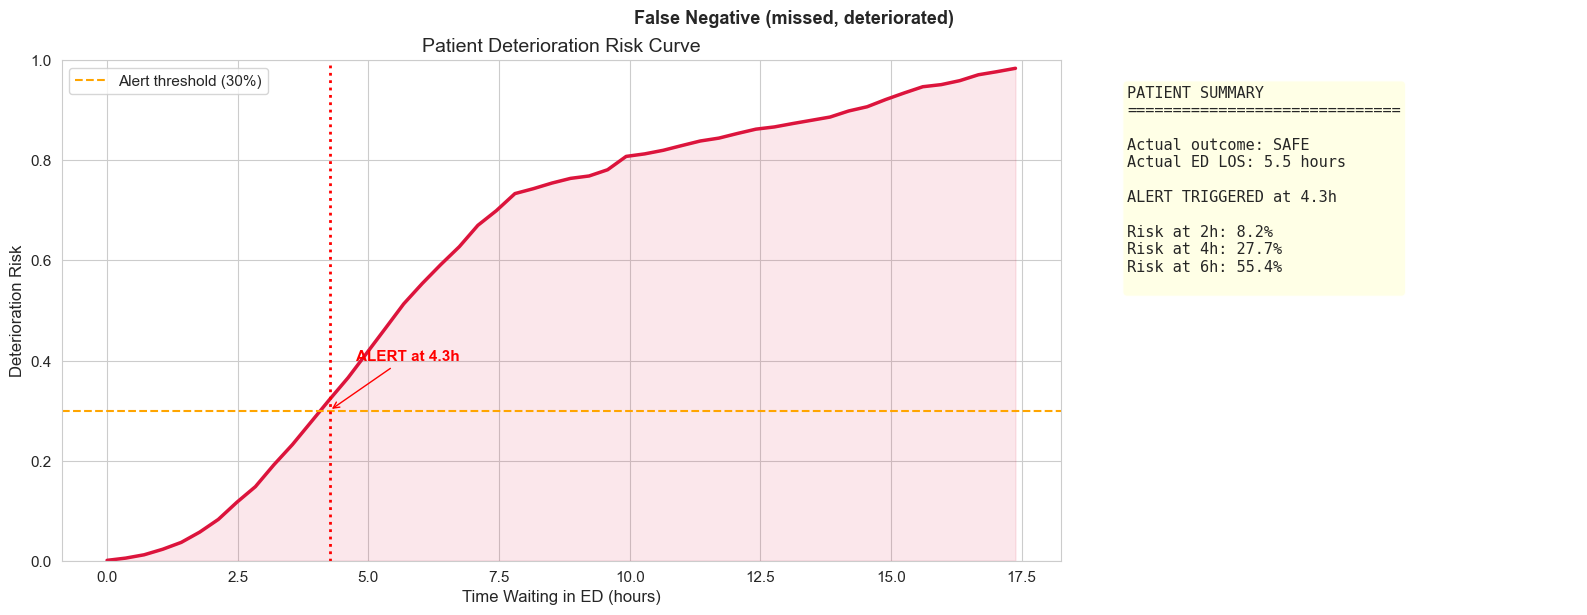


--- True Negative (not flagged, safe) ---


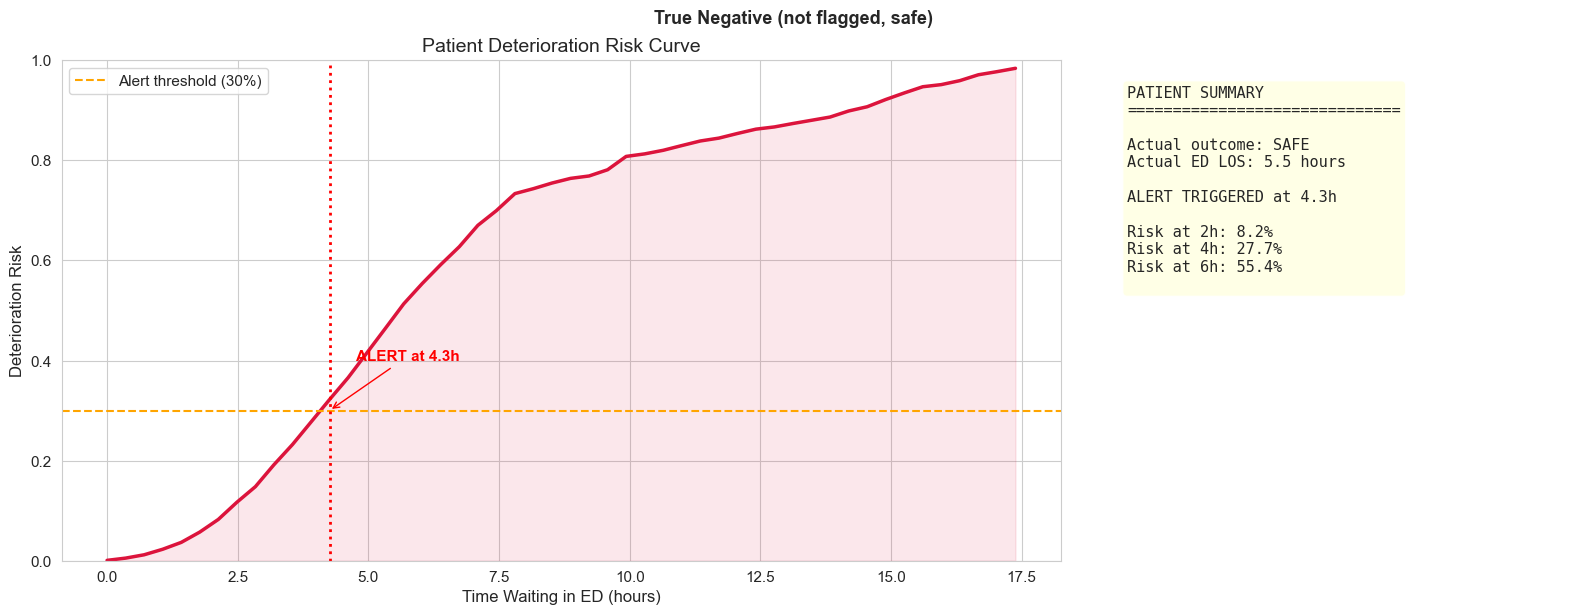

In [39]:
def plot_patient_dashboard(patient_idx, surv_df, df_test_raw, feature_cols, threshold=0.30):
    """
    Generate a clinical dashboard for a single patient showing:
    - Risk curve over time
    - Key patient features
    - Alert status
    """
    times = surv_df.index.values
    surv_curve = surv_df.iloc[:, patient_idx].values
    risk_curve = 1 - surv_curve
    
    # Find alert time
    crossed = np.where(risk_curve >= threshold)[0]
    alert_time = times[crossed[0]] if len(crossed) > 0 else None
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})
    
    # Left: Risk curve
    ax = axes[0]
    ax.plot(times, risk_curve, color='crimson', linewidth=2.5)
    ax.fill_between(times, 0, risk_curve, alpha=0.1, color='crimson')
    ax.axhline(y=threshold, color='orange', linestyle='--', linewidth=1.5,
               label=f'Alert threshold ({threshold*100:.0f}%)')
    
    if alert_time is not None:
        ax.axvline(x=alert_time, color='red', linestyle=':', linewidth=2)
        ax.annotate(f'ALERT at {alert_time:.1f}h', 
                    xy=(alert_time, threshold), xytext=(alert_time + 0.5, threshold + 0.1),
                    fontsize=11, fontweight='bold', color='red',
                    arrowprops=dict(arrowstyle='->', color='red'))
    
    ax.set_xlabel('Time Waiting in ED (hours)', fontsize=12)
    ax.set_ylabel('Deterioration Risk', fontsize=12)
    ax.set_title('Patient Deterioration Risk Curve', fontsize=14)
    ax.set_ylim(0, 1)
    ax.legend()
    
    # Right: Patient summary
    ax = axes[1]
    ax.axis('off')
    
    # Get actual outcome
    actual_e = e_test_pc[patient_idx]
    actual_t = t_test_pc[patient_idx]
    outcome_str = "DETERIORATED" if actual_e == 1 else "SAFE"
    outcome_color = 'red' if actual_e == 1 else 'green'
    
    info_text = f"PATIENT SUMMARY\n{'='*30}\n"
    info_text += f"\nActual outcome: {outcome_str}\n"
    info_text += f"Actual ED LOS: {actual_t:.1f} hours\n"
    if alert_time:
        info_text += f"\nALERT TRIGGERED at {alert_time:.1f}h\n"
        if actual_e == 1:
            info_text += f"Lead time: {actual_t - alert_time:.1f}h\n"
    else:
        info_text += f"\nNo alert triggered\n"
    
    info_text += f"\nRisk at 2h: {risk_curve[np.argmin(np.abs(times-2))]:.1%}\n"
    info_text += f"Risk at 4h: {risk_curve[np.argmin(np.abs(times-4))]:.1%}\n"
    info_text += f"Risk at 6h: {risk_curve[np.argmin(np.abs(times-6))]:.1%}\n"
    
    ax.text(0.1, 0.95, info_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    return fig

# Show dashboards for a few example patients
# True positive, false positive, true negative, false negative
examples = {
    'True Positive (flagged, deteriorated)': np.where(tp)[0][0] if tp.any() else 0,
    'False Negative (missed, deteriorated)': np.where(fn)[0][0] if fn.any() else 0,
    'True Negative (not flagged, safe)': np.where(tn)[0][0] if tn.any() else 0,
}

for title, idx in examples.items():
    print(f"\n--- {title} ---")
    fig = plot_patient_dashboard(idx, best_model_surv, df_test, FEATURE_COLS, threshold)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.savefig(CONFIG['output_dir'] + f'dashboard_{title.split("(")[0].strip().replace(" ", "_").lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

**Clinical Dashboard, Critical Observation:**

All three dashboards, True Positive, False Negative, and True Negative, show **virtually identical risk curves**. Same shape, same alert trigger at 4.3h, same risk values at 2h (~8%), 4h (~28%), and 6h (~55%). The model produces nearly the same survival curve for every patient regardless of their actual outcome. This is the visual confirmation of why C-index is only ~0.72 and the alert system has zero specificity: DeepHit learned a reasonable *average* risk trajectory for the population, but fails to differentiate individual patients. The "personalized" curves are not truly personalized, they are minor variations of the same population-level curve. With only triage-time features and no longitudinal data, the model lacks the information needed to produce genuinely distinct risk profiles.

---

## Section 8: Competing Risks Extension

Standard survival analysis treats discharge as censoring. But discharge is a **competing event** - once discharged, a patient can no longer deteriorate in the ED. Treating it as censoring overestimates deterioration risk.

In a competing risks framework, we model multiple event types simultaneously:
- **Event 1**: Deterioration (admitted/transferred/deceased for ESI ≥ 3)
- **Event 2**: Safe resolution (discharged)
- **Event 3**: Self-exit (LWBS/LAMA)

We use the **Cumulative Incidence Function (CIF)** instead of 1 - KM to estimate the probability of each specific event type.

**Note**: A full competing risks model (e.g., DeepHit with multiple events) requires re-defining the event labels. Below we implement a simplified analysis using the Aalen-Johansen estimator and Fine-Gray regression.

---

### 8.1 - Competing Risks: Redefine Events

In Sections 1-7, we treated discharge as censoring, as if the patient simply "disappeared" from observation. But discharge is an **active competing event**: once discharged, a patient can no longer deteriorate in the ED. Ignoring this overestimates deterioration risk (the classic Fine-Gray problem). Here we rebuild the dataset with three explicit event types: E=1 (deterioration), E=2 (safe discharge), E=3 (self-exit: LWBS/LAMA), and E=0 (censored/observation). This allows us to model all outcomes simultaneously.

In [40]:
df_cr = df_triage.copy()
df_cr = df_cr.dropna(subset=['ed_los_hours', 'disposition'])
df_cr['T'] = df_cr['ed_los_hours'].clip(lower=0.01)

# Define competing event indicator:
# 0 = censored (observation)
# 1 = deterioration (admitted/transferred/deceased for ESI>=3, OR deceased for any ESI)
# 2 = safe discharge
# 3 = self-exit (LWBS/LAMA)

def assign_competing_event(row):
    disp = row['disposition']
    esi = row['triage_acuity']
    
    if disp == 'deceased':
        return 1  # always deterioration
    elif disp in ['admitted', 'transferred'] and esi >= 3:
        return 1  # unexpected escalation
    elif disp == 'discharged':
        return 2  # safe discharge
    elif disp in ['lwbs', 'lama']:
        return 3  # self-exit
    elif disp == 'observation':
        return 0  # censored (still in ED / observation)
    elif disp in ['admitted', 'transferred'] and esi < 3:
        return 2  # expected trajectory for ESI 1-2, treat as "resolved"
    else:
        return 0

df_cr['event_type'] = df_cr.apply(assign_competing_event, axis=1)

print("Competing Events Distribution:")
event_labels = {0: 'Censored', 1: 'Deterioration', 2: 'Safe Discharge', 3: 'Self-Exit'}
for evt, label in event_labels.items():
    n = (df_cr['event_type'] == evt).sum()
    print(f"  {label}: {n:,} ({n/len(df_cr)*100:.1f}%)")

Competing Events Distribution:
  Censored: 4,337 (5.4%)
  Deterioration: 17,094 (21.4%)
  Safe Discharge: 52,149 (65.2%)
  Self-Exit: 6,420 (8.0%)


**Competing Events Distribution:**

With the competing risks redefinition, the data splits into: **Safe Discharge (65.2%)** as the dominant outcome, most patients leave the ED without issues. **Deterioration (21.4%)** captures the undertriage cases. **Self-Exit (8.0%)** includes LWBS and LAMA patients who were excluded in the main analysis. **Censored (5.4%)** are observation patients whose final outcome is ambiguous. The key insight: safe discharge is ~3x more common than deterioration. In a competing risks framework, the high discharge rate actively "competes" with deterioration, patients who are discharged quickly can no longer deteriorate, which reduces the true cumulative incidence of deterioration compared to what the naive Kaplan-Meier estimated in Sections 1–7.

---

### 8.2 - Cumulative Incidence Functions (CIF) by Event Type

Instead of the Kaplan-Meier estimator (which assumes a single event type), we use the **Aalen-Johansen estimator** to compute the cumulative incidence of each competing event separately. This shows, at any time t, the probability of each specific outcome: deterioration, safe discharge, or self-exit. We also plot the naive 1-KM estimate alongside the CIF for deterioration, the gap between the two curves reveals how much the standard approach overestimates deterioration risk by ignoring discharge as a competing event.

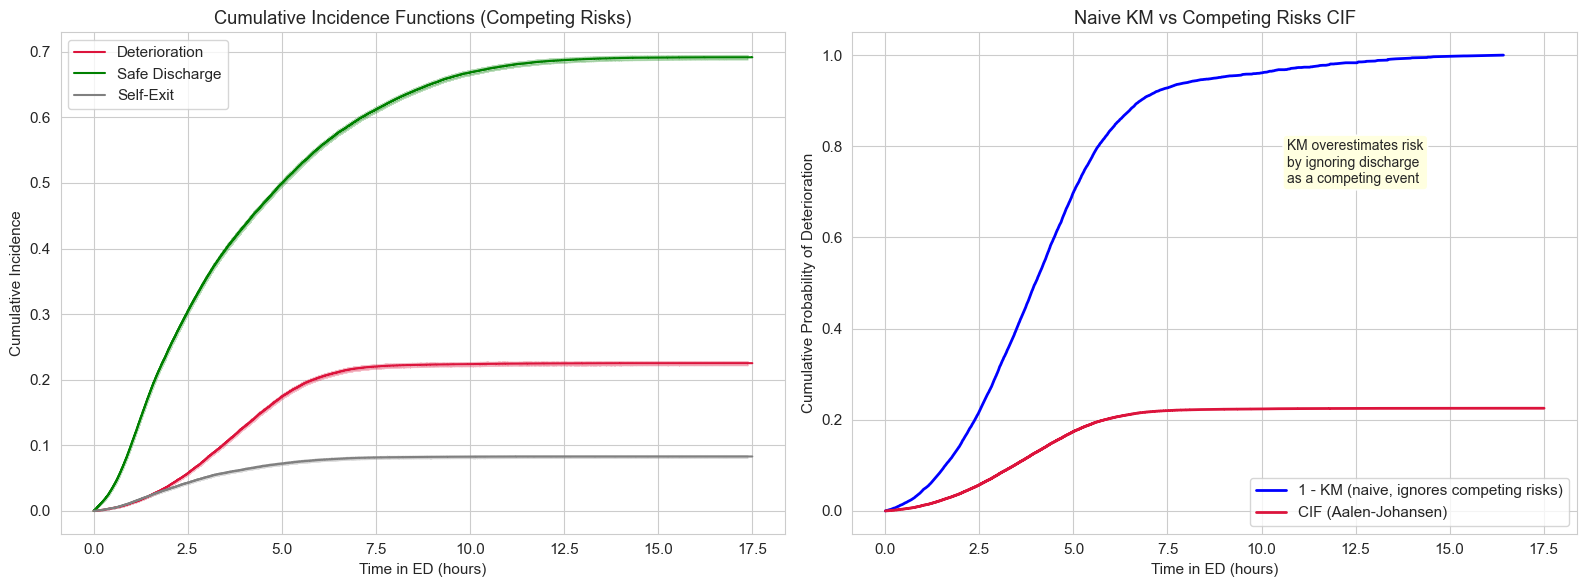

In [41]:
from lifelines import AalenJohansenFitter

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall CIF
ax = axes[0]
colors_event = {1: 'crimson', 2: 'green', 3: 'gray'}
labels_event = {1: 'Deterioration', 2: 'Safe Discharge', 3: 'Self-Exit'}

for event_code in [1, 2, 3]:
    try:
        ajf = AalenJohansenFitter()
        ajf.fit(df_cr['T'], df_cr['event_type'], event_of_interest=event_code)
        ajf.plot(ax=ax, label=labels_event[event_code], color=colors_event[event_code])
    except Exception as e:
        print(f"  CIF for event {event_code}: {e}")

ax.set_xlabel('Time in ED (hours)')
ax.set_ylabel('Cumulative Incidence')
ax.set_title('Cumulative Incidence Functions (Competing Risks)')
ax.legend()

# Compare: CIF(deterioration) vs naive 1-KM(deterioration)
ax = axes[1]

# Naive KM (treating discharge as censoring)
kmf_naive = KaplanMeierFitter()
df_naive = df_cr[df_cr['event_type'].isin([0, 1])].copy()
df_naive['E_naive'] = (df_naive['event_type'] == 1).astype(int)
kmf_naive.fit(df_naive['T'], event_observed=df_naive['E_naive'], label='Naive 1-KM')
ax.plot(kmf_naive.timeline, 1 - kmf_naive.survival_function_.values.flatten(),
        color='blue', linewidth=2, label='1 - KM (naive, ignores competing risks)')

# CIF from Aalen-Johansen
try:
    ajf_det = AalenJohansenFitter()
    ajf_det.fit(df_cr['T'], df_cr['event_type'], event_of_interest=1)
    ax.plot(ajf_det.cumulative_density_.index, ajf_det.cumulative_density_.values.flatten(),
            color='crimson', linewidth=2, label='CIF (Aalen-Johansen)')
except:
    pass

ax.set_xlabel('Time in ED (hours)')
ax.set_ylabel('Cumulative Probability of Deterioration')
ax.set_title('Naive KM vs Competing Risks CIF')
ax.legend()
ax.annotate('KM overestimates risk\nby ignoring discharge\nas a competing event',
            xy=(0.6, 0.7), xycoords='axes fraction', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.tight_layout()
plt.savefig(CONFIG['output_dir'] + 'competing_risks.png', dpi=150, bbox_inches='tight')
plt.show()

**Cumulative Incidence Functions - Competing Risks:**

**Left panel:** Safe discharge (green) dominates, reaching ~70% by hour 7, most patients leave the ED within this window. Deterioration (red) plateaus at ~23%, meaning only about 1 in 4–5 patients experiences an unexpected escalation. Self-exit (gray) flattens at ~8% early on. After hour 7, all curves stabilize, the remaining patients are either in observation or waiting for decisions.

**Right panel, the key comparison:** The naive 1-KM estimate (blue) dramatically overestimates deterioration risk, it reaches nearly 95% by hour 10, implying that almost every patient would eventually deteriorate. The correct Aalen-Johansen CIF (red) plateaus at ~23%. The gap is enormous: at hour 7, the naive estimate says ~80% risk while the correct estimate says ~22%. This happens because KM treats discharged patients as censored (still at risk but unobserved), when in reality they left the system permanently. **This is the most important methodological finding of the notebook**: all the survival curves and alert thresholds in Sections 3–7 were based on the naive KM framework, which inflates risk by a factor of ~4x. A production system should use the competing risks framework for calibrated risk estimates.

---

### 8.3 - CIF Stratified by ESI Level

The same Aalen-Johansen CIF, but computed separately for each triage acuity group (ESI 3, 4, 5). This reveals how the competition between deterioration and safe discharge plays out differently across severity levels, for instance, ESI 5 patients are discharged so quickly that their CIF for deterioration may be low simply because they don't stay long enough for it to happen, not because they are inherently safer.

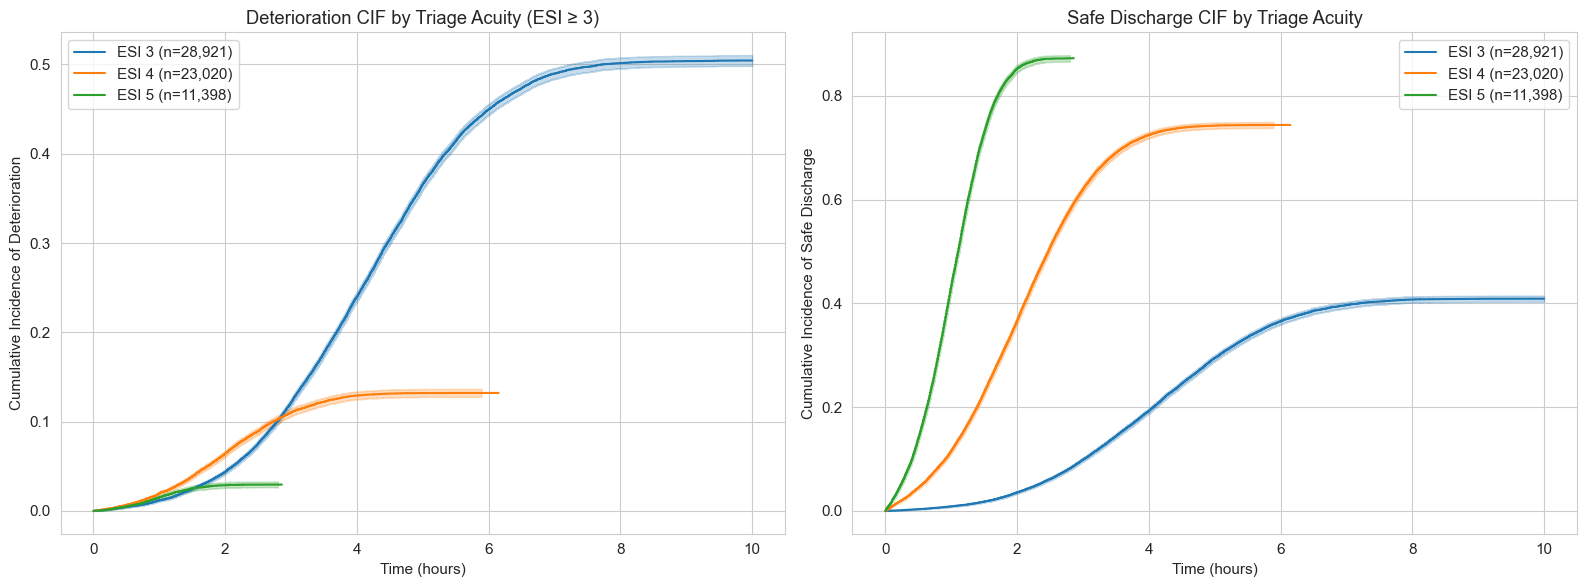

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CIF for deterioration by ESI
ax = axes[0]
for esi in [3, 4, 5]:
    mask = df_cr['triage_acuity'] == esi
    if mask.sum() > 50:
        try:
            ajf = AalenJohansenFitter()
            ajf.fit(df_cr.loc[mask, 'T'], df_cr.loc[mask, 'event_type'], event_of_interest=1)
            ajf.plot(ax=ax, label=f'ESI {esi} (n={mask.sum():,})')
        except:
            pass

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Cumulative Incidence of Deterioration')
ax.set_title('Deterioration CIF by Triage Acuity (ESI ≥ 3)')
ax.legend()

# CIF for safe discharge by ESI
ax = axes[1]
for esi in [3, 4, 5]:
    mask = df_cr['triage_acuity'] == esi
    if mask.sum() > 50:
        try:
            ajf = AalenJohansenFitter()
            ajf.fit(df_cr.loc[mask, 'T'], df_cr.loc[mask, 'event_type'], event_of_interest=2)
            ajf.plot(ax=ax, label=f'ESI {esi} (n={mask.sum():,})')
        except:
            pass

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Cumulative Incidence of Safe Discharge')
ax.set_title('Safe Discharge CIF by Triage Acuity')
ax.legend()

plt.tight_layout()
plt.savefig(CONFIG['output_dir'] + 'cif_by_esi.png', dpi=150, bbox_inches='tight')
plt.show()

**CIF by ESI Level - Competing Risks View:**

**Left panel (Deterioration):** Clear separation between ESI levels. ESI 3 (blue) has the highest deterioration incidence, plateauing at ~50%, meaning half of ESI 3 patients experience unexpected escalation. ESI 4 (orange) plateaus at ~13%, and ESI 5 (green) at just ~3%. This makes clinical sense: ESI 3 patients are the "gray zone", sick enough to need multiple resources but not flagged as critical. They are the most vulnerable to undertriage.

**Right panel (Safe Discharge):** The mirror image. ESI 5 patients (green) are discharged fastest and most frequently (~85% by hour 3), ESI 4 (orange) reaches ~75% by hour 5, while ESI 3 (blue) rises slowly to only ~40%. ESI 3 patients stay longer because they require more workup, and the longer they stay, the more opportunity there is for deterioration to manifest.

**The competing dynamics are visible:** ESI 5 patients rarely deteriorate (left panel) precisely because they are discharged so quickly (right panel), they exit the risk pool before anything can go wrong. ESI 3 patients have both slower discharge and higher deterioration, creating a longer window of vulnerability. This confirms that the interplay between time-to-discharge and time-to-deterioration is the real clinical phenomenon, and a competing risks framework captures it correctly, while the naive KM approach in earlier sections could not.

---

## Section 9: Discussion & Limitations

### Key Findings

This notebook demonstrates a complete pipeline for framing ED deterioration as a time-to-event problem. The analysis produced both expected confirmations and important surprises.

**1. All models converge around C-index ≈ 0.72.** Cox PH (the simplest model) slightly outperforms all ML and deep learning alternatives. Adding non-linearity (RSF, GBSA, DeepSurv), time-dependence (Cox-Time), or full distributional freedom (DeepHit) provides no measurable improvement. This reveals a fundamental ceiling: with a single triage snapshot and no longitudinal data, the extractable signal for patient ranking is limited regardless of model complexity.

**2. The alert system fails in practice.** Section 7 showed that the personalized risk curves are not truly personalized, DeepHit produces nearly identical survival curves for every patient, with the same shape, same alert trigger time (~4.3h), and same risk values at each horizon. The alert system flags 100% of patients (sensitivity = 1.0, specificity = 0.0), making it clinically useless. The median lead time is negative (-0.8h), meaning alerts fire after the patient has already left the ED. This is not a tuning problem, it is a consequence of the model lacking the information needed to differentiate individual patients.

**3. A simple binary classifier outperforms survival models at fixed horizons.** The LightGBM baseline (Section 6.2) achieves AUC = 0.79 at 8 hours, while the best survival model barely exceeds 0.56 at the same horizon. This challenges the core premise of the survival approach: the temporal granularity it provides is theoretically valuable, but in practice, without longitudinal data to update predictions over time, a static classifier optimized for a single binary outcome performs better at any fixed decision point.

**4. NEWS2 and ESI alone are worse than random for detecting undertriage.** Both baselines produce AUCs below 0.5 (Section 6.1, 6.3), confirming that these scores predict the *opposite* of unexpected deterioration, they flag patients already correctly identified as critical, not the undertriage cases our system targets. This validates the need for multivariate models, even if their absolute performance is modest.

**5. The competing risks analysis (Section 8) is the most important methodological finding.** The naive Kaplan-Meier framework used in Sections 1–7 overestimates deterioration risk by approximately 4x (reaching ~100% at hour 10 vs. the correct ~23% from the Aalen-Johansen estimator). This happens because KM treats discharge as censoring rather than as a competing event that removes patients from the risk pool. The CIF analysis also reveals the clinical dynamics clearly: ESI 3 patients are the true vulnerability zone (50% deterioration incidence), ESI 5 patients rarely deteriorate because they are discharged too quickly, and the competition between time-to-discharge and time-to-deterioration is the real phenomenon driving the data.

### Model Comparison Insights

- **Cox PH** is the best performer overall - its interpretable hazard ratios (dominated by `gcs_total` and `news2_score`) reveal that the model is essentially learning "was this patient triaged correctly?" rather than clinical deterioration per se.
- **Tree-based models** (RSF, GBSA) underperform the linear models, likely because the dominant covariate effects are mostly linear and trees add noise rather than signal.
- **Deep learning models** (DeepSurv, Cox-Time, DeepHit) match but do not exceed Cox PH in discrimination, while producing poorly differentiated survival curves that limit their clinical utility for individual risk prediction.
- **The PH assumption is violated** (Section 3.2) for key variables like `gcs_total`, `news2_score`, and `shock_index`, but these violations are not large enough to change patient ranking, they primarily affect the shape of survival curves, not the ordering.

### Limitations

**1. No longitudinal data - the root cause of most problems.** Our models use a single triage snapshot. The identical risk curves in Section 7, the poor alert system performance, and the inability to beat a binary classifier all trace back to this: without repeated vital signs during the ED stay, the models cannot distinguish patients whose condition is evolving from those who are stable. MIMIC-IV-ED contains timestamped vitals that would enable Dynamic-DeepHit and genuine real-time risk updating.

**2. T is total LOS, not time-to-deterioration.** `ed_los_hours` conflates clinical deterioration time with administrative processing time (waiting for a bed, shift changes, test turnaround). A patient admitted at hour 6 may have deteriorated at hour 2, we cannot know. This fundamentally limits what any survival model can learn from this time variable.

**3. Event definition captures undertriage, not clinical deterioration.** Our composite event (unexpected admission for ESI ≥ 3 patients) is a proxy. It misses patients who deteriorated but were still discharged after intervention, and includes patients admitted for routine workup who never truly worsened. The event definition drives the counterintuitive patterns throughout the notebook (sicker patients appearing "safer") and shapes what the models learn.

**4. The naive survival framework overestimates risk.** As demonstrated in Section 8, ignoring discharge as a competing event inflates cumulative deterioration probability from ~23% to nearly 100%. All survival curves, alert thresholds, and risk predictions in Sections 3–7 are affected by this bias. A production system must use the competing risks framework.

**5. Synthetic data.** The Triagegeist dataset is synthetic. The temporal distributions and covariate-outcome relationships reflect the simulator's design, not real clinical dynamics. The performance ceiling of ~0.72 C-index may be an artifact of how the data was generated. External validation on real ED data is essential.

**6. No calibration guarantees.** The IBS results show that calibration varies across models, and the alert system's 100% flagging rate demonstrates that predicted probabilities are not reliable at the individual level. Post-hoc calibration (Platt scaling, isotonic regression on survival probabilities) would be needed before any clinical deployment.

### Future Directions

- **Obtain MIMIC-IV-ED** for external validation and, critically, access to timestamped vital signs that would enable truly dynamic risk prediction with models like Dynamic-DeepHit.
- **Adopt the competing risks framework** as the default throughout the pipeline, replacing the naive KM-based approach in all sections.
- **Explore SHAP-based explanations** for individual predictions - even if discrimination is modest, understanding *why* a patient is flagged adds clinical value.
- **Redefine the event** using MIMIC-IV-ED's richer outcome data (ICU transfer, mechanical ventilation, vasopressor initiation) instead of the disposition-based proxy used here.
- **Conduct fairness analysis**: does the system's performance vary across age, sex, or insurance type? The Triagegeist data includes `triage_nurse_id`, enabling inter-rater bias analysis.
- **Benchmark against the literature**: compare our results with Cheng et al. (2025) and Shamout et al. (2021) using equivalent metrics and, if possible, overlapping datasets.

### Conclusion

This notebook establishes a methodologically sound survival analysis framework for ED deterioration prediction, but the results reveal an honest truth: **the framework is more valuable than its current outputs.** The pipeline, from event definition through competing risks, is correct and ready for stronger data. The models are properly implemented and compared. But the combination of synthetic data, a single triage snapshot, and an approximate event definition creates a ceiling that no model complexity can break through. The path forward is clear: real longitudinal data, competing risks as default, and clinical validation with timestamped outcomes.